# Task 3: Occasion and Gender Classification


## 1. Introduction

This notebook is for **Task 3: Occasion and Gender Classification** for Assignment 2 predicting catalog gender category and intended occasion of a fashion product from its RGB image. **The task is cast as two separate multi-class classification problems: One model to predict gender, the other to predict occasion (the metadata field `usage`).**

We implement and train from scratch three neural-network methods using TensorFlow/Keras:

- **Shallow MLP (Baseline):** Fully connected with one 256-unit hidden layer on flattened image pixels.
- **Deeper MLP:** A fully connected network with 256, 128 and 64 hidden units in the layers, with dropout to prevent overfitting.
- **Convolutional Neural Network (CNN):** A spatial model which learns local image patterns via convolutional layers. The CNN family has three declared architecture/scheduling configurations.

Performance is evaluated through:

- **Accuracy:** Percentage of images correctly classified.
- **Macro-F1**: The main selection metric, with equal weight to F1 scores of classes present in evaluation partition.
- **Classification reports and confusion matrices per class**: Evidence of which labels are well-recognized and which are confusable.
- **Learning curves:** We used training and validation loss, accuracy and macro-F1 to analyze convergence and overfitting.
- **Calibration metrics:** Confidence calibration of the selected model, evaluated after selection with different validation groups.

Note that gender labels refer to the catalog category, rather than the identity of a person in an image. Labels of occasions may visually overlap, accuracy may be dominated by frequent categories. Each target is trained, compared, and evaluated independently.

The workflow comprises metadata inspection, preprocessing, model development, comparative evaluation, selection, and export for prediction. All candidates work with the same frozen group isolated data partitions. A limitation is that the internal test has been exposed to previous development, even if retraining is performed. The numerical results and the final model decision have to be derived from the newly conducted results. No winner is assumed in advance.

## 2. Library Imports & Setup

Use the Fashion Keras kernel. The seed controls initialization and augmentation. Float32 is used throughout; GPU availability is reported before models are created.

In [ ]:
# Locate the project, import the training libraries, select the accelerator, and fix random seeds.
from pathlib import Path
import sys, json
from concurrent.futures import ThreadPoolExecutor

ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image, ImageEnhance
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_recall_fscore_support,
    classification_report,
    log_loss,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import GroupShuffleSplit
from scipy.optimize import minimize_scalar
import tensorflow as tf
from tensorflow import keras
from scripts.preprocessing import (
    task_frame,
    IMAGE_SIZE,
    NORMALISATION_PATH,
    SEED,
    select_tensorflow_device,
)

DEVICE = select_tensorflow_device()
keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()
OUTPUT, RESULTS = (ROOT / 'models', ROOT / 'results')
for directory in (OUTPUT, RESULTS):
    directory.mkdir(parents=True, exist_ok=True)
MAX_EPOCHS, BATCH_SIZE = (30, 64)

def stem_for(target):
    return 'article_type' if target == 'articleType' else target

get_ipython().run_line_magic('matplotlib', 'inline')

# False for a fresh Run All. Enable only when deliberately resuming matching saved experiments.
RESUME_SAVED_RESULTS = False

2026-09-12 01:44:42.547026: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-09-12 01:44:42.597783: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


2026-09-12 01:44:43.532917: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


TensorFlow 2.20.0: /GPU:0


## 3. Load Metadata

Load valid labelled images and their frozen split assignments. Inspect paths, target labels and missing values before preprocessing.

In [2]:
# Load audited metadata and show how many labelled images are available in each frozen split.
metadata_by_target = {'gender': task_frame('gender'), 'usage': task_frame('usage')}
frame = metadata_by_target['gender']
print('gender', frame.shape)
display(frame.head())
frame = metadata_by_target['usage']
print('usage', frame.shape)
display(frame.head())

gender (38611, 15)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,productDisplayName_repaired,image_path,has_image,group_key,split
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_0,train
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_1,train
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_2,train
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_3,train
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_4,train


usage (38610, 15)


,id,gender,masterCategory,subCategory,articleType,baseColour,season,year,usage,productDisplayName,productDisplayName_repaired,image_path,has_image,group_key,split
0,1163,Men,Apparel,Topwear,Tshirts,Blue,Summer,2011,Sports,Nike Sahara Team India Fanwear Round Neck Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_0,train
1,1164,Men,Apparel,Topwear,Tshirts,Blue,Winter,2015,Sports,Nike Men Blue T20 Indian Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_1,train
2,1165,Men,Apparel,Topwear,Tshirts,Blue,Summer,2013,Sports,Nike Mean Team India Cricket Jersey,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_2,train
3,1525,Unisex,Accessories,Bags,Backpacks,Navy Blue,Fall,2010,Casual,Puma Deck Navy Blue Backpack,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_3,train
4,1526,Unisex,Accessories,Bags,Backpacks,Black,Fall,2010,Sports,Puma Big Cat Backpack Black,False,/mnt/d/khoile/programs/fashion-intelligence-cl...,True,group_4,train


## 4. Data Preprocessing

Prepare the same images and label encoding for every candidate. Preserve group isolation and fit normalization on training data only.

### 4.1. Class Distribution & Balancing

Preserve the original sample distribution. Initial candidates use unweighted cross-entropy; additional CNN experiments compare this with capped square-root inverse-frequency weights computed only from training counts. No examples are duplicated, and validation metrics remain unweighted.

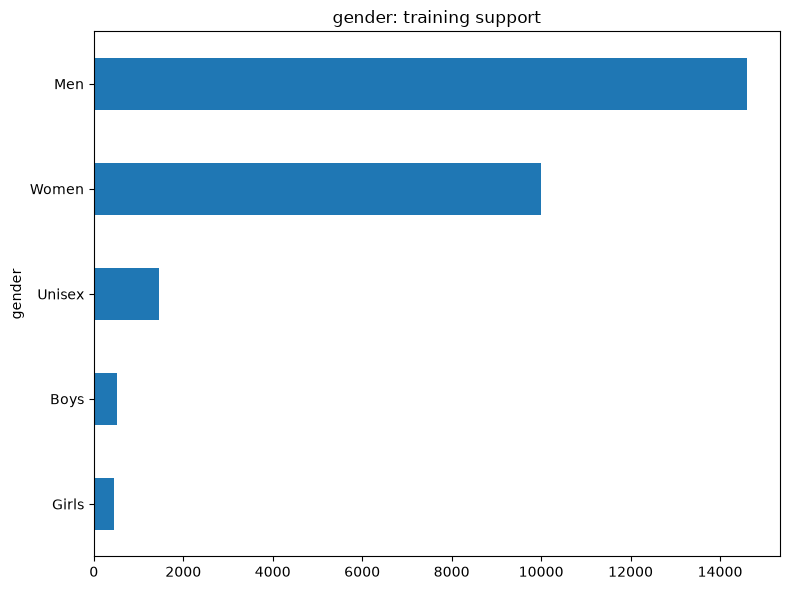

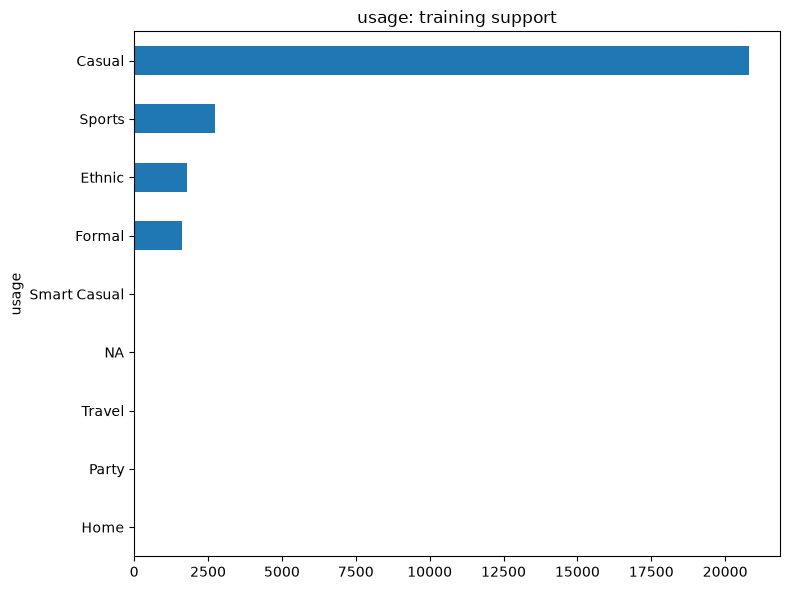

In [3]:
# Measure training-set class imbalance before choosing architectures and evaluation metrics.
train_rows = metadata_by_target['gender'].loc[metadata_by_target['gender']['split'].eq('train')]
counts = train_rows['gender'].value_counts()
counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f"{'gender'}: training support")
plt.tight_layout()
plt.show()
train_rows = metadata_by_target['usage'].loc[metadata_by_target['usage']['split'].eq('train')]
counts = train_rows['usage'].value_counts()
counts.head(25).sort_values().plot.barh(figsize=(8, 6), title=f"{'usage'}: training support")
plt.tight_layout()
plt.show()

### 4.2. Training, Validation & Test Partitions

Reuse the frozen product-group split. Within validation, use separate groups for selection, temperature fitting and policy checking. Do not use the internal test to select candidates.

In [4]:
# Divide validation groups into model-selection and calibration views without splitting related products.
def validation_views(frame):
    selection_ids, rest_ids = next(
        GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED).split(
            frame, groups=frame.group_key
        )
    )
    selection, rest = frame.iloc[selection_ids], frame.iloc[rest_ids]
    cal_ids, policy_ids = next(
        GroupShuffleSplit(n_splits=1, train_size=0.5, random_state=SEED + 1).split(
            rest, groups=rest.group_key
        )
    )
    return selection, rest.iloc[cal_ids], rest.iloc[policy_ids]

In [5]:
# Create the split views, fixed label order, and reusable batch loaders for each target.
frames, labels_by_target = ({}, {})
selection, calibration, policy = validation_views(
    metadata_by_target['gender'].loc[metadata_by_target['gender']['split'].eq('validation')]
)
frames['gender'] = dict(
    train=metadata_by_target['gender'].loc[metadata_by_target['gender']['split'].eq('train')],
    selection=selection,
    calibration=calibration,
    policy=policy,
)
groups = [set(frame.group_key) for frame in frames['gender'].values()]
assert all((a.isdisjoint(b) for i, a in enumerate(groups) for b in groups[i + 1 :]))
labels_by_target['gender'] = sorted(frames['gender']['train']['gender'].unique())
display(pd.Series({name: len(frame) for name, frame in frames['gender'].items()}, name='gender'))
selection, calibration, policy = validation_views(
    metadata_by_target['usage'].loc[metadata_by_target['usage']['split'].eq('validation')]
)
frames['usage'] = dict(
    train=metadata_by_target['usage'].loc[metadata_by_target['usage']['split'].eq('train')],
    selection=selection,
    calibration=calibration,
    policy=policy,
)
groups = [set(frame.group_key) for frame in frames['usage'].values()]
assert all((a.isdisjoint(b) for i, a in enumerate(groups) for b in groups[i + 1 :]))
labels_by_target['usage'] = sorted(frames['usage']['train']['usage'].unique())
display(pd.Series({name: len(frame) for name, frame in frames['usage'].items()}, name='usage'))

train          27051
selection       2900
calibration     1378
policy          1564
Name: gender, dtype: int64

train          27050
selection       2900
calibration     1378
policy          1564
Name: usage, dtype: int64

### 4.3. Image Preprocessing

Resize RGB to 96 x 128 pixels (width x height), then normalize using training-only channel statistics. The batch class stores decoded uint8 images and converts one batch at a time to float32. Horizontal flips are applied inside each model only during training.

In [6]:
# Cache resized images in RAM and serve normalized batches to Keras during training and evaluation.
class CachedBatches(keras.utils.PyDataset):
    """Decode RGB once to uint8 RAM, then normalize each NHWC batch."""

    def __init__(self, frame, target, labels, normalisation, training=False, batch_size=64):
        super().__init__(workers=0, max_queue_size=2)
        self.dataset = frame
        self.training, self.batch_size = training, batch_size

        def read(path):
            with Image.open(path) as image:
                return np.asarray(
                    image.convert("RGB").resize(IMAGE_SIZE, Image.Resampling.BILINEAR)
                ).copy()

        # Decode and resize each source image once; later epochs reuse this cache.
        with ThreadPoolExecutor(max_workers=4) as pool:
            self.images = np.stack(list(pool.map(read, frame.image_path)))

        # Convert string labels to the fixed integer order expected by the output layer.
        self.targets = np.asarray([labels.index(label) for label in frame[target]], dtype=np.int32)
        self.mean = np.asarray(normalisation["mean"], dtype=np.float32)
        self.std = np.asarray(normalisation["std"], dtype=np.float32)
        self.reset()

    def reset(self):
        self.rng = np.random.default_rng(SEED)
        self.indices = np.arange(len(self.dataset))
        if self.training:
            self.rng.shuffle(self.indices)

    def __len__(self):
        return (len(self.dataset) + self.batch_size - 1) // self.batch_size

    # Normalize only the requested batch to avoid storing a second float32 image copy.
    def __getitem__(self, index):
        ids = self.indices[index * self.batch_size : (index + 1) * self.batch_size]
        images = self.images[ids].astype(np.float32) / 255.0
        return (images - self.mean) / self.std, self.targets[ids]

    def on_epoch_end(self):
        if self.training:
            self.rng.shuffle(self.indices)

### 4.4. Feature Batches & Label Encoding

Map sorted label names to integer indices, preserving the same order for every model. Construct shuffled training batches and fixed-order selection batches.

In [7]:
# Load normalization statistics computed from training images only, then construct all data loaders.
normalisation = json.loads(NORMALISATION_PATH.read_text())
loaders = {}
labels = labels_by_target['gender']
loaders['gender'] = {
    name: CachedBatches(
        frames['gender'][name],
        'gender',
        labels,
        normalisation,
        training=name == 'train',
        batch_size=BATCH_SIZE,
    )
    for name in ['train', 'selection']
}
labels = labels_by_target['usage']
loaders['usage'] = {
    name: CachedBatches(
        frames['usage'][name],
        'usage',
        labels,
        normalisation,
        training=name == 'train',
        batch_size=BATCH_SIZE,
    )
    for name in ['train', 'selection']
}

## 5. Model Development & Evaluation

Train and evaluate a shallow MLP baseline, a deeper MLP and a CNN using the same image preprocessing and frozen partitions. Architecture construction, fitting, class-level evaluation, calibration and model export are implemented in this notebook.

### Evaluation Metric: Macro-F1

Aggregate confusion matrix over full epoch and average F1 per class with positive ground-truth support. This metric chooses the restored epoch and the winning model. It does not average F1 scores per batch.

The per-class classification report and each output label for coverage auditing are also shown. Hence its regular `macro avg` row includes zero-support output labels and may be different from the macro-F1 used for selection, which is based on supported classes. Before making claims about all classes, read the selection metric that was explicitly reported for model ranking and check support. For this frozen run, selection support is 97/124 article types, 4/4 seasons, 5/5 gender categories, 8/9 occasion labels.

In [8]:
# Track macro-F1 across a complete epoch with a running confusion matrix.
@keras.utils.register_keras_serializable(package="Fashion")
class SupportedMacroF1(keras.metrics.Metric):
    """Macro-F1 over classes present in the full epoch's ground truth."""

    def __init__(self, num_classes, name="macro_f1", **kwargs):
        super().__init__(name=name, **kwargs)
        self.num_classes = num_classes
        self.matrix = self.add_weight(
            name="matrix", shape=(num_classes, num_classes), initializer="zeros"
        )

    # Accumulate one confusion matrix across all batches in the epoch.
    def update_state(self, y_true, y_pred, sample_weight=None):
        truth = tf.cast(tf.reshape(y_true, [-1]), tf.int32)
        predictions = tf.argmax(y_pred, axis=-1, output_type=tf.int32)
        weights = (
            None if sample_weight is None else tf.cast(tf.reshape(sample_weight, [-1]), self.dtype)
        )
        self.matrix.assign_add(
            tf.math.confusion_matrix(
                truth, predictions, self.num_classes, weights=weights, dtype=self.dtype
            )
        )

    # Average F1 only across classes that are present in the ground truth.
    def result(self):
        support = tf.reduce_sum(self.matrix, axis=1)
        predicted = tf.reduce_sum(self.matrix, axis=0)
        f1 = tf.math.divide_no_nan(2 * tf.linalg.diag_part(self.matrix), support + predicted)
        mask = tf.cast(support > 0, self.dtype)
        return tf.math.divide_no_nan(tf.reduce_sum(f1 * mask), tf.reduce_sum(mask))

    def reset_state(self):
        self.matrix.assign(tf.zeros_like(self.matrix))

    def get_config(self):
        return {**super().get_config(), "num_classes": self.num_classes}

### Saved-Model Metadata

An identity layer stores label order, preprocessing and confidence policy inside each exported Keras model.

In [9]:
# Attach labels and preprocessing settings to the exported Keras model as a pass-through layer.
@keras.utils.register_keras_serializable(package="Fashion")
class ModelMetadata(keras.layers.Layer):
    """Store label order, preprocessing and calibration inside the .keras file."""

    def __init__(self, metadata=None, **kwargs):
        super().__init__(**kwargs)
        self.metadata = dict(metadata or {})

    def call(self, inputs):
        return inputs

    def get_config(self):
        return {**super().get_config(), "metadata": dict(self.metadata)}

In [10]:
# Keep trained models, learning histories, and selection scores organized by target and method.
models = {'gender': {}, 'usage': {}}
histories = {'gender': {}, 'usage': {}}
selection_scores = {}

### General design justification

Standardized batch and inference with a fixed 96x128 RGB input, to keep the computation manageable. Its portrait aspect ratio is the dominant 60x80 source format. Resizing cannot recover missing detail, so larger inputs are not assumed to improve recognition. Output units are aligned to the label vocabulary of the target not a free-tuned capacity setting.

Flattening provides a simple pixel-based baseline. A shallow MLP tests if one nonlinear hidden layer is enough, and a deeper MLP tests for more nonlinear transformations. Dense layers do not explicitly preserve local spatial relations and flattening leads to huge parameter counts. ReLU adds non-linearity. The hidden widths and depths are selected based on validation evidence rather than the number of classes.

Small 3x3 convolutions are weight shared across positions and can learn local appearance patterns. The successive blocks enable to merge information from larger image regions. Max pooling reduces spatial dimensions and computational cost, but can lose fine detail. The dense head has its size limited by the final 2x2 average-pooled grid, but maintains a coarse spatial layout. Batch normalization stabilizes the scale of intermediate activations. These design properties motivate the use of CNN; they do not prove that a particular learned filter detects a particular garment feature.

Dropout 0.2 prevents models from relying on individual hidden activations. Training-only horizontal flips expose models to mirrored product views. They are attempts to improve generalization, not guaranties. Adam adapts parameter updates; reducing its learning rate on a validation plateau allows for smaller updates later in CNN training. Early stopping restores the best selection macro-F1 epoch and stops training when improvement stalls. The fixed seed is for repeatability and batch size 64 is a practical setting of training, not a demonstrated optima.

The group-isolated partitions prevent related-product leakage; the training-only normalization prevents fitting preprocessing to evaluation data; and the macro-F1 gives equal weight to each supported class. Additional evidence comes from accuracy, class-level errors and parameter counts. The specific choices were justified by the measured validation comparison, the general principles above explain their intended roles, with different labels favoring different capacities.

In [11]:
SELECTED_CONFIGS = {
    'gender': {
        'shallow_mlp': {
            'method': 'shallow_mlp_lower_lr',
            'widths': [256],
            'learning_rate': 0.0001,
            'epochs': 20,
            'patience': 4,
        },
        'deeper_mlp': {
            'method': 'deeper_mlp_two_layers',
            'widths': [256, 128],
            'learning_rate': 0.0003,
            'epochs': 20,
            'patience': 4,
        },
        'cnn': {
            'method': 'cnn_four_blocks_scheduled',
            'widths': [256],
            'learning_rate': 0.001,
            'epochs': 30,
            'patience': 7,
        },
    },
    'usage': {
        'shallow_mlp': {
            'method': 'shallow_mlp_lower_lr',
            'widths': [256],
            'learning_rate': 0.0001,
            'epochs': 20,
            'patience': 4,
        },
        'deeper_mlp': {
            'method': 'deeper_mlp',
            'widths': [256, 128, 64],
            'learning_rate': 0.001,
            'epochs': 30,
            'patience': 7,
        },
        'cnn': {
            'method': 'cnn_continue_weighted',
            'widths': [256],
            'learning_rate': 3e-05,
            'epochs': 30,
            'patience': 7,
        },
    },
}

### 5.1. Shallow MLP (Baseline)

Flattened RGB input is passed through the selected dense layers, with ReLU and dropout 0.2 after each hidden layer.

#### 5.1.1. Gender: Model Architecture & Training Configuration

Configuration `shallow_mlp_lower_lr`; hidden dense units [256]. Adam 0.0001, maximum 20 epochs, early-stopping patience 4.

In [12]:
# Build the shallow MLP from the selected target-specific configuration.
config = SELECTED_CONFIGS['gender']['shallow_mlp']
method = config['method']
keras.utils.set_random_seed(SEED)

# Start with a fixed image input and training-only horizontal augmentation.
layers = [
    keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)),
    keras.layers.RandomFlip('horizontal'),
]
layers.append(keras.layers.Flatten())

# Add the configured hidden classifier layers and dropout regularization.
for width in config['widths']:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['gender'])), ModelMetadata(name='metadata')])
models['gender'][method] = keras.Sequential(layers, name=method)
models['gender'][method].summary()

I0000 00:00:1789152403.147284   48875 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 9709 MB memory:  -> device: 0, name: NVIDIA GeForce RTX 3060, pci bus id: 0000:01:00.0, compute capability: 8.6


Model: "shallow_mlp_lower_lr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │         1,285 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,438,725 (36.01 MB)

 Trainable params: 9,438,725 (36.01 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.1.2. Gender: Compile & Train Model

The selection view controls epoch selection. Test images are excluded from training.

In [13]:
# Compile and train the model while restoring the epoch with the best selection macro-F1.
model = models['gender'][method]

# Configure optimization and report both accuracy and imbalance-aware macro-F1.
model.compile(
    optimizer=keras.optimizers.Adam(0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['gender'])),
    ],
)
loaders['gender']['train'].reset()

# Stop when selection macro-F1 no longer improves and restore its best weights.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True
    )
]

# Keep the selection partition read-only: it chooses epochs but never updates weights.
fitted = model.fit(
    loaders['gender']['train'],
    validation_data=loaders['gender']['selection'],
    epochs=20,
    callbacks=callbacks,
    shuffle=False,
    verbose=2,
)
histories['gender'][method] = pd.DataFrame(fitted.history)

Epoch 1/20


423/423 - 12s - 28ms/step - accuracy: 0.7737 - loss: 0.6562 - macro_f1: 0.5008 - val_accuracy: 0.8121 - val_loss: 0.5504 - val_macro_f1: 0.5726


Epoch 2/20


423/423 - 11s - 25ms/step - accuracy: 0.8170 - loss: 0.5379 - macro_f1: 0.5889 - val_accuracy: 0.8210 - val_loss: 0.4906 - val_macro_f1: 0.5999


Epoch 3/20


...

423/423 - 11s - 26ms/step - accuracy: 0.8564 - loss: 0.4075 - macro_f1: 0.6760 - val_accuracy: 0.8386 - val_loss: 0.4909 - val_macro_f1: 0.6720


Epoch 11/20


423/423 - 10s - 25ms/step - accuracy: 0.8566 - loss: 0.4150 - macro_f1: 0.6836 - val_accuracy: 0.8586 - val_loss: 0.4660 - val_macro_f1: 0.7000


Epoch 12/20


423/423 - 11s - 25ms/step - accuracy: 0.8633 - loss: 0.3800 - macro_f1: 0.6877 - val_accuracy: 0.8531 - val_loss: 0.4376 - val_macro_f1: 0.7105


In [ ]:
# Shared plotting helper, reused by each model's evaluation below.
def plot_confusion_figure(counts, target, title):
    """Display row-normalized confusion counts without running inference."""
    # Normalize over every predicted class before selecting rows for display.
    normalized = counts.div(counts.sum(axis=1).replace(0, 1), axis=0)
    fig, ax = plt.subplots(figsize=(9, 7))
    display_matrix = ConfusionMatrixDisplay(normalized.to_numpy(), display_labels=counts.index)
    display_matrix.plot(ax=ax, cmap='Blues', values_format='.2f', xticks_rotation=45)
    display_matrix.im_.set_clim(0, 1)
    # A label with no test examples has undefined recall.
    for row in np.flatnonzero(counts.sum(axis=1).to_numpy() == 0):
        for annotation in display_matrix.text_[row]:
            annotation.set_text('N/A')
    ax.set_title(title)
    ax.set(xlabel='Predicted label', ylabel='True label')
    fig.tight_layout()
    plt.show()
    plt.close(fig)


#### 5.1.3. Gender: Evaluation and Performance Metrics

Calculate validation accuracy and supported-class macro-F1, display the per-class classification report, and plot training and validation loss, accuracy and macro-F1. These measurements use the restored best epoch.

selection_accuracy    0.846897
selection_macro_f1    0.711753
dtype: float64

,precision,recall,f1-score,support
Boys,0.763889,0.733333,0.748299,75.000000
Girls,0.625000,0.588235,0.606061,51.000000
Men,0.884615,0.898883,0.891692,1612.000000
Unisex,0.690476,0.360248,0.473469,161.000000
Women,0.816635,0.863137,0.839242,1001.000000
accuracy,0.846897,0.846897,0.846897,0.846897
macro avg,0.756123,0.688767,0.711753,2900.000000
weighted avg,0.842685,0.846897,0.841638,2900.000000


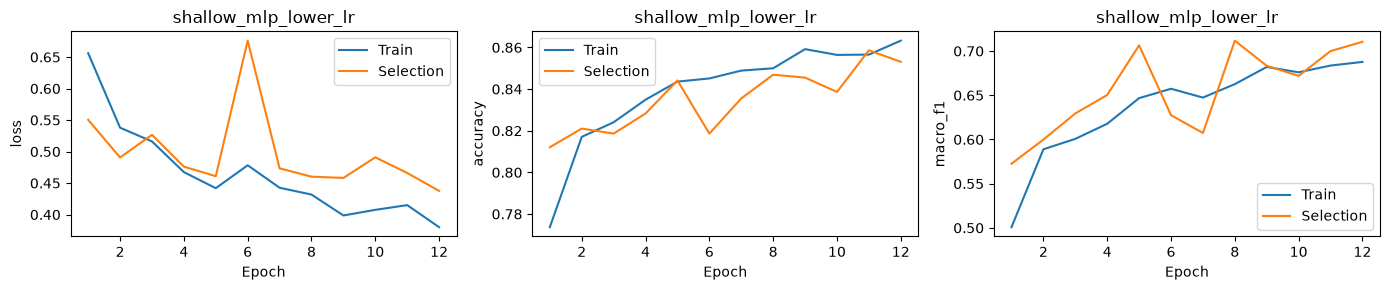

In [ ]:
# Evaluate the restored best weights, show class metrics, and plot the learning curves.
loader = loaders['gender']['selection']

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(models['gender'][method](loader[i][0], training=False)).numpy()
        for i in range(len(loader))
    ]
)
predictions = probabilities.argmax(1)
display(
    pd.Series(
        dict(
            selection_accuracy=accuracy_score(loader.targets, predictions),
            selection_macro_f1=f1_score(
                loader.targets,
                predictions,
                labels=np.unique(loader.targets),
                average='macro',
                zero_division=0,
            ),
        )
    )
)

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        loader.targets,
        predictions,
        labels=np.arange(len(labels_by_target['gender'])),
        target_names=labels_by_target['gender'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / f"{stem_for('gender')}_{method}_selection_per_class.csv")

# Plot train and selection curves to diagnose convergence and overfitting.
history = histories['gender'][method]
history.to_csv(RESULTS / f"{stem_for('gender')}_{method}_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
    ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
    ax.plot(np.arange(1, len(history) + 1), history['val_' + metric], label='Selection')
    ax.set(xlabel='Epoch', ylabel=metric, title=method)
    ax.legend()
fig.tight_layout()
plt.show()

# Store one comparable row for the final cross-family decision.
selection_scores.setdefault('gender', {})[method] = dict(
    family='shallow_mlp',
    validation_accuracy=accuracy_score(loader.targets, predictions),
    validation_macro_f1=f1_score(
        loader.targets,
        predictions,
        labels=np.unique(loader.targets),
        average='macro',
        zero_division=0,
    ),
    complexity_parameters=models['gender'][method].count_params(),
    epochs_run=len(history),
)

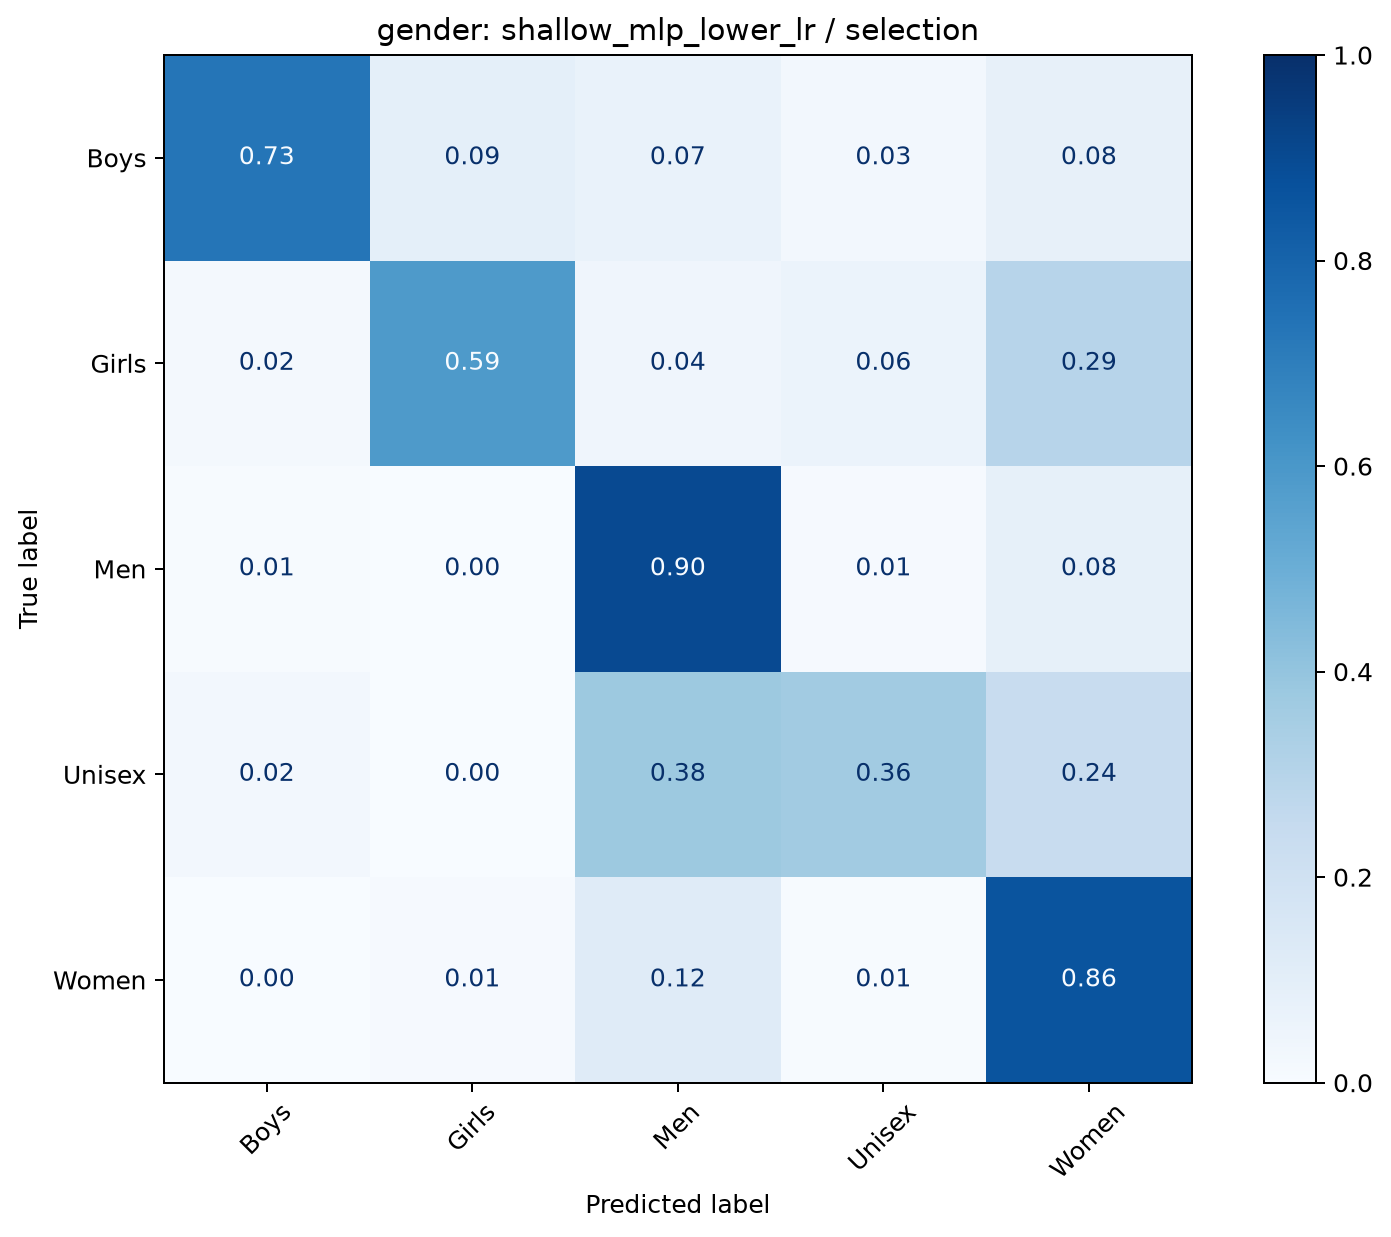

In [ ]:
# Plot this model's selection matrix using the predictions calculated above.
labels = labels_by_target['gender']
counts = pd.DataFrame(
    tf.math.confusion_matrix(loader.targets, predictions, num_classes=len(labels)).numpy(),
    index=labels, columns=labels,
)
plot_confusion_figure(
    counts, 'gender', f'gender: {method} / selection',
)

#### 5.1.4. Gender: Evaluation Analysis

The Shallow MLP achieved 84.69% selection accuracy and 0.7118 supported-class macro-F1 with 9,438,725 parameters. The best macro-F1 epoch was 8/12 in the training run. The training accuracy at this epoch was 85.00%, training loss 0.4318 and selection loss 0.4602. The small accuracy gap is not much evidence of serious overfitting. The two evaluation conditions differ by the dropout and training-only augmentation.

The precision, recall and F1 for Men is 0.885, 0.899 and 0.892 (n=1612) respectively, Women 0.817, 0.863 and 0.839 (n=1001), Boys 0.764, 0.733 and 0.748 (n=75), Girls 0.625, 0.588 and 0.606 (n=51) and Unisex 0.690, 0.360 and 0.473 (n=161) . 0 of 5 represented classes have zero recall. The macro-F1 supported-class does not consider classes not included in this partition. 

The dense model compares on flattened pixels, but does not beat the CNN on selection macro-F1. Additional depth does not, in itself, mean better generalization. These results characterize this completed run; broader claims are constrained by minority support and a single random seed.

#### 5.1.5. Occasion: Model Architecture & Training Configuration

Configuration `shallow_mlp_lower_lr`; hidden dense units [256]. Adam 0.0001, maximum 20 epochs, early-stopping patience 4.

In [15]:
# Build the shallow MLP from the selected target-specific configuration.
config = SELECTED_CONFIGS['usage']['shallow_mlp']
method = config['method']
keras.utils.set_random_seed(SEED)

# Start with a fixed image input and training-only horizontal augmentation.
layers = [
    keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)),
    keras.layers.RandomFlip('horizontal'),
]
layers.append(keras.layers.Flatten())

# Add the configured hidden classifier layers and dropout regularization.
for width in config['widths']:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['usage'])), ModelMetadata(name='metadata')])
models['usage'][method] = keras.Sequential(layers, name=method)
models['usage'][method].summary()

Model: "shallow_mlp_lower_lr"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_1 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 9)              │         2,313 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 9)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,439,753 (36.01 MB)

 Trainable params: 9,439,753 (36.01 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.1.6. Occasion: Compile & Train Model

The selection view controls epoch selection. Test images are excluded from training.

In [16]:
# Compile and train the model while restoring the epoch with the best selection macro-F1.
model = models['usage'][method]

# Configure optimization and report both accuracy and imbalance-aware macro-F1.
model.compile(
    optimizer=keras.optimizers.Adam(0.0001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['usage'])),
    ],
)
loaders['usage']['train'].reset()

# Stop when selection macro-F1 no longer improves and restore its best weights.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True
    )
]

# Keep the selection partition read-only: it chooses epochs but never updates weights.
fitted = model.fit(
    loaders['usage']['train'],
    validation_data=loaders['usage']['selection'],
    epochs=20,
    callbacks=callbacks,
    shuffle=False,
    verbose=2,
)
histories['usage'][method] = pd.DataFrame(fitted.history)

Epoch 1/20


423/423 - 12s - 29ms/step - accuracy: 0.8059 - loss: 0.6590 - macro_f1: 0.2581 - val_accuracy: 0.8352 - val_loss: 0.5188 - val_macro_f1: 0.3129


Epoch 2/20


423/423 - 11s - 26ms/step - accuracy: 0.8315 - loss: 0.5274 - macro_f1: 0.2896 - val_accuracy: 0.8531 - val_loss: 0.5089 - val_macro_f1: 0.3496


Epoch 3/20


...

423/423 - 11s - 27ms/step - accuracy: 0.8731 - loss: 0.3799 - macro_f1: 0.4032 - val_accuracy: 0.8645 - val_loss: 0.4911 - val_macro_f1: 0.4411


Epoch 13/20


423/423 - 11s - 27ms/step - accuracy: 0.8751 - loss: 0.3754 - macro_f1: 0.4030 - val_accuracy: 0.8583 - val_loss: 0.4870 - val_macro_f1: 0.4046


Epoch 14/20


423/423 - 11s - 27ms/step - accuracy: 0.8725 - loss: 0.4130 - macro_f1: 0.3607 - val_accuracy: 0.8579 - val_loss: 0.5543 - val_macro_f1: 0.3954


#### 5.1.7. Occasion: Evaluation and Performance Metrics

Calculate validation accuracy and supported-class macro-F1, display the per-class classification report, and plot training and validation loss, accuracy and macro-F1. These measurements use the restored best epoch.

selection_accuracy    0.873793
selection_macro_f1    0.452185
dtype: float64

,precision,recall,f1-score,support
Casual,0.896203,0.949486,0.922075,2237.000000
Ethnic,0.770186,0.746988,0.758410,166.000000
Formal,0.829932,0.685393,0.750769,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,1.000000,0.400000,0.571429,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.736364,0.527687,0.614801,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.873793,0.873793,0.873793,0.873793


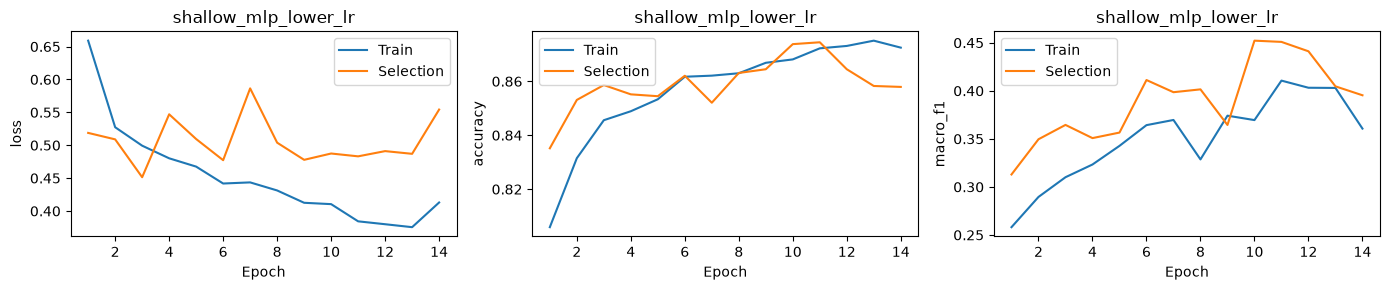

In [ ]:
# Evaluate the restored best weights, show class metrics, and plot the learning curves.
loader = loaders['usage']['selection']

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(models['usage'][method](loader[i][0], training=False)).numpy()
        for i in range(len(loader))
    ]
)
predictions = probabilities.argmax(1)
display(
    pd.Series(
        dict(
            selection_accuracy=accuracy_score(loader.targets, predictions),
            selection_macro_f1=f1_score(
                loader.targets,
                predictions,
                labels=np.unique(loader.targets),
                average='macro',
                zero_division=0,
            ),
        )
    )
)

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        loader.targets,
        predictions,
        labels=np.arange(len(labels_by_target['usage'])),
        target_names=labels_by_target['usage'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / f"{stem_for('usage')}_{method}_selection_per_class.csv")

# Plot train and selection curves to diagnose convergence and overfitting.
history = histories['usage'][method]
history.to_csv(RESULTS / f"{stem_for('usage')}_{method}_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
    ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
    ax.plot(np.arange(1, len(history) + 1), history['val_' + metric], label='Selection')
    ax.set(xlabel='Epoch', ylabel=metric, title=method)
    ax.legend()
fig.tight_layout()

plt.show()

# Store one comparable row for the final cross-family decision.
selection_scores.setdefault('usage', {})[method] = dict(
    family='shallow_mlp',
    validation_accuracy=accuracy_score(loader.targets, predictions),
    validation_macro_f1=f1_score(
        loader.targets,
        predictions,
        labels=np.unique(loader.targets),
        average='macro',
        zero_division=0,
    ),
    complexity_parameters=models['usage'][method].count_params(),
    epochs_run=len(history),
)

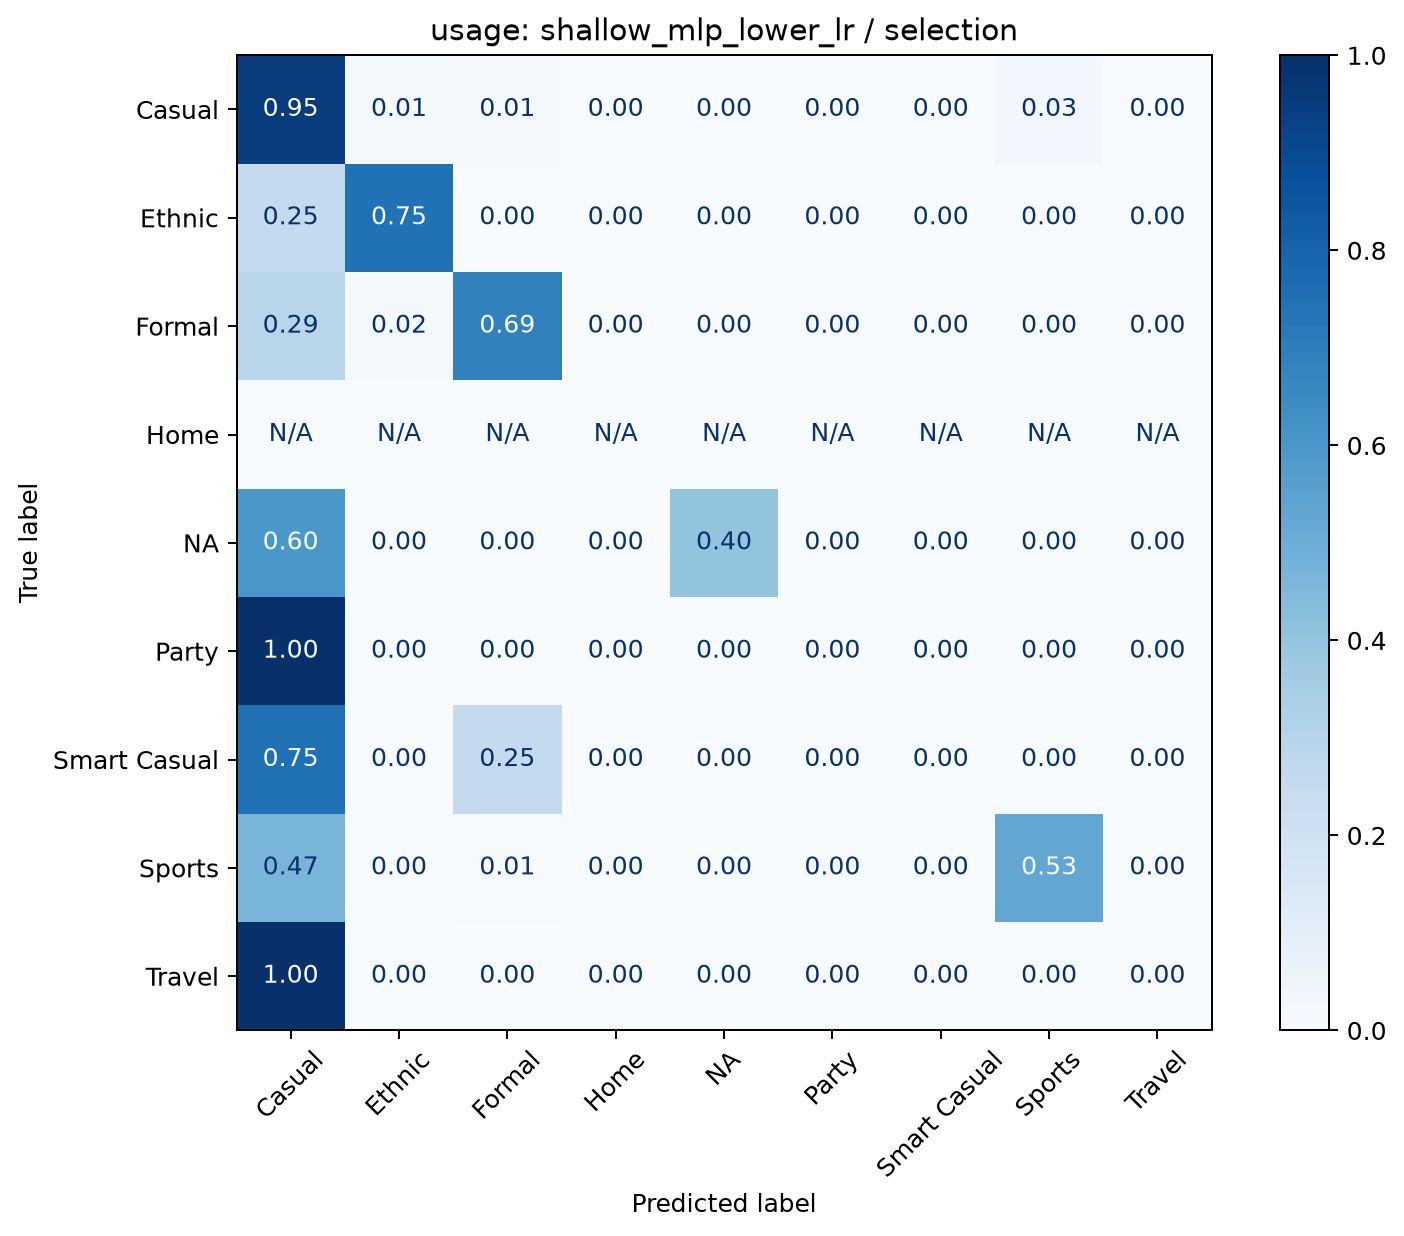

In [ ]:
# Plot this model's selection matrix using the predictions calculated above.
labels = labels_by_target['usage']
counts = pd.DataFrame(
    tf.math.confusion_matrix(loader.targets, predictions, num_classes=len(labels)).numpy(),
    index=labels, columns=labels,
)
plot_confusion_figure(
    counts, 'usage', f'usage: {method} / selection',
)

#### 5.1.8. Occasion: Evaluation Analysis

The Shallow MLP achieved 87.38% selection accuracy and 0.4522 supported class macro-F1 with 9439753 parameters. The best macro-F1 epoch was 10 out of 14 in the training run. At that epoch, the training accuracy was 86.81%, the training loss was 0.4105 and the selection loss was 0.4874. The small accuracy gap is not much evidence of severe overfitting. The two evaluation conditions differ due to dropout and training-only augmentation.

Casual: precision 0.896, recall 0.949 and F1 0.922 (n = 2237); Ethnic: precision 0.770, recall 0.747 and F1 0.758 (n = 166); Formal: precision 0.830, recall 0.685 and F1 0.751 (n = 178); Sports: precision 0.736, recall 0.528 and F1 0.615 (n = 307); NA: precision 1.000, recall 0.400 and F1 0.571 (n = 5). The recall for 3 of the 8 classes represented is zero. Classes not appearing in this partition are excluded from the supported-class macro-F1. Party, Smart Casual and Travel have only one, four and two examples respectively and none is recovered. The literal NA is a label for a data set, not a blank value. 

The dense model offers a comparison with flat pixels but it does not outperform the CNN in terms of selection macro-F1. Additional depth does not, in itself, mean better generalization. These results characterize this completed run; broader claims are constrained by minority support and a single random seed.

### 5.2. Deeper MLP

Flattened RGB input is passed through the selected dense layers, with ReLU and dropout 0.2 after each hidden layer.

#### 5.2.1. Gender: Model Architecture & Training Configuration

Configuration `deeper_mlp_two_layers`; hidden dense units [256, 128]. Adam 0.0003, maximum 20 epochs, early-stopping patience 4.

In [18]:
# Build the deeper MLP from the selected target-specific configuration.
config = SELECTED_CONFIGS['gender']['deeper_mlp']
method = config['method']
keras.utils.set_random_seed(SEED)

# Start with a fixed image input and training-only horizontal augmentation.
layers = [
    keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)),
    keras.layers.RandomFlip('horizontal'),
]
layers.append(keras.layers.Flatten())

# Add the configured hidden classifier layers and dropout regularization.
for width in config['widths']:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['gender'])), ModelMetadata(name='metadata')])
models['gender'][method] = keras.Sequential(layers, name=method)
models['gender'][method].summary()

Model: "deeper_mlp_two_layers"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_2 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 5)              │           645 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 5)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,470,981 (36.13 MB)

 Trainable params: 9,470,981 (36.13 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2.2. Gender: Compile & Train Model

The selection view controls epoch selection. Test images are excluded from training.

In [19]:
# Compile and train the model while restoring the epoch with the best selection macro-F1.
model = models['gender'][method]

# Configure optimization and report both accuracy and imbalance-aware macro-F1.
model.compile(
    optimizer=keras.optimizers.Adam(0.0003),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['gender'])),
    ],
)
loaders['gender']['train'].reset()

# Stop when selection macro-F1 no longer improves and restore its best weights.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True
    )
]

# Keep the selection partition read-only: it chooses epochs but never updates weights.
fitted = model.fit(
    loaders['gender']['train'],
    validation_data=loaders['gender']['selection'],
    epochs=20,
    callbacks=callbacks,
    shuffle=False,
    verbose=2,
)
histories['gender'][method] = pd.DataFrame(fitted.history)

Epoch 1/20


423/423 - 12s - 28ms/step - accuracy: 0.7155 - loss: 0.9405 - macro_f1: 0.3980 - val_accuracy: 0.7855 - val_loss: 0.6092 - val_macro_f1: 0.5163


Epoch 2/20


423/423 - 11s - 26ms/step - accuracy: 0.7700 - loss: 0.6840 - macro_f1: 0.4659 - val_accuracy: 0.7997 - val_loss: 0.5679 - val_macro_f1: 0.5118


Epoch 3/20


...

423/423 - 11s - 27ms/step - accuracy: 0.8407 - loss: 0.4479 - macro_f1: 0.6088 - val_accuracy: 0.8452 - val_loss: 0.4664 - val_macro_f1: 0.6912


Epoch 19/20


423/423 - 11s - 27ms/step - accuracy: 0.8446 - loss: 0.4327 - macro_f1: 0.6258 - val_accuracy: 0.8403 - val_loss: 0.4649 - val_macro_f1: 0.6387


Epoch 20/20


423/423 - 11s - 26ms/step - accuracy: 0.8421 - loss: 0.4264 - macro_f1: 0.6219 - val_accuracy: 0.8428 - val_loss: 0.4518 - val_macro_f1: 0.6886


#### 5.2.3. Gender: Evaluation and Performance Metrics

Calculate validation accuracy and supported-class macro-F1, display the per-class classification report, and plot training and validation loss, accuracy and macro-F1. These measurements use the restored best epoch.

selection_accuracy    0.845172
selection_macro_f1    0.691177
dtype: float64

,precision,recall,f1-score,support
Boys,0.886792,0.626667,0.734375,75.000000
Girls,0.642857,0.529412,0.580645,51.000000
Men,0.862406,0.929280,0.894595,1612.000000
Unisex,0.723077,0.291925,0.415929,161.000000
Women,0.829511,0.831169,0.830339,1001.000000
accuracy,0.845172,0.845172,0.845172,0.845172
macro avg,0.788929,0.641691,0.691177,2900.000000
weighted avg,0.840086,0.845172,0.836177,2900.000000


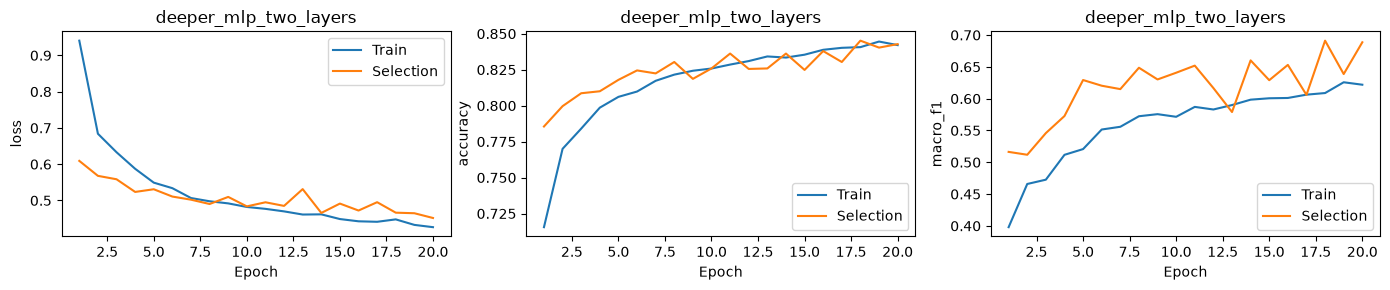

In [ ]:
# Evaluate the restored best weights, show class metrics, and plot the learning curves.
loader = loaders['gender']['selection']

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(models['gender'][method](loader[i][0], training=False)).numpy()
        for i in range(len(loader))
    ]
)
predictions = probabilities.argmax(1)
display(
    pd.Series(
        dict(
            selection_accuracy=accuracy_score(loader.targets, predictions),
            selection_macro_f1=f1_score(
                loader.targets,
                predictions,
                labels=np.unique(loader.targets),
                average='macro',
                zero_division=0,
            ),
        )
    )
)

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        loader.targets,
        predictions,
        labels=np.arange(len(labels_by_target['gender'])),
        target_names=labels_by_target['gender'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / f"{stem_for('gender')}_{method}_selection_per_class.csv")

# Plot train and selection curves to diagnose convergence and overfitting.
history = histories['gender'][method]
history.to_csv(RESULTS / f"{stem_for('gender')}_{method}_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
    ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
    ax.plot(np.arange(1, len(history) + 1), history['val_' + metric], label='Selection')
    ax.set(xlabel='Epoch', ylabel=metric, title=method)
    ax.legend()
fig.tight_layout()
plt.show()

# Store one comparable row for the final cross-family decision.
selection_scores.setdefault('gender', {})[method] = dict(
    family='deeper_mlp',
    validation_accuracy=accuracy_score(loader.targets, predictions),
    validation_macro_f1=f1_score(
        loader.targets,
        predictions,
        labels=np.unique(loader.targets),
        average='macro',
        zero_division=0,
    ),
    complexity_parameters=models['gender'][method].count_params(),
    epochs_run=len(history),
)

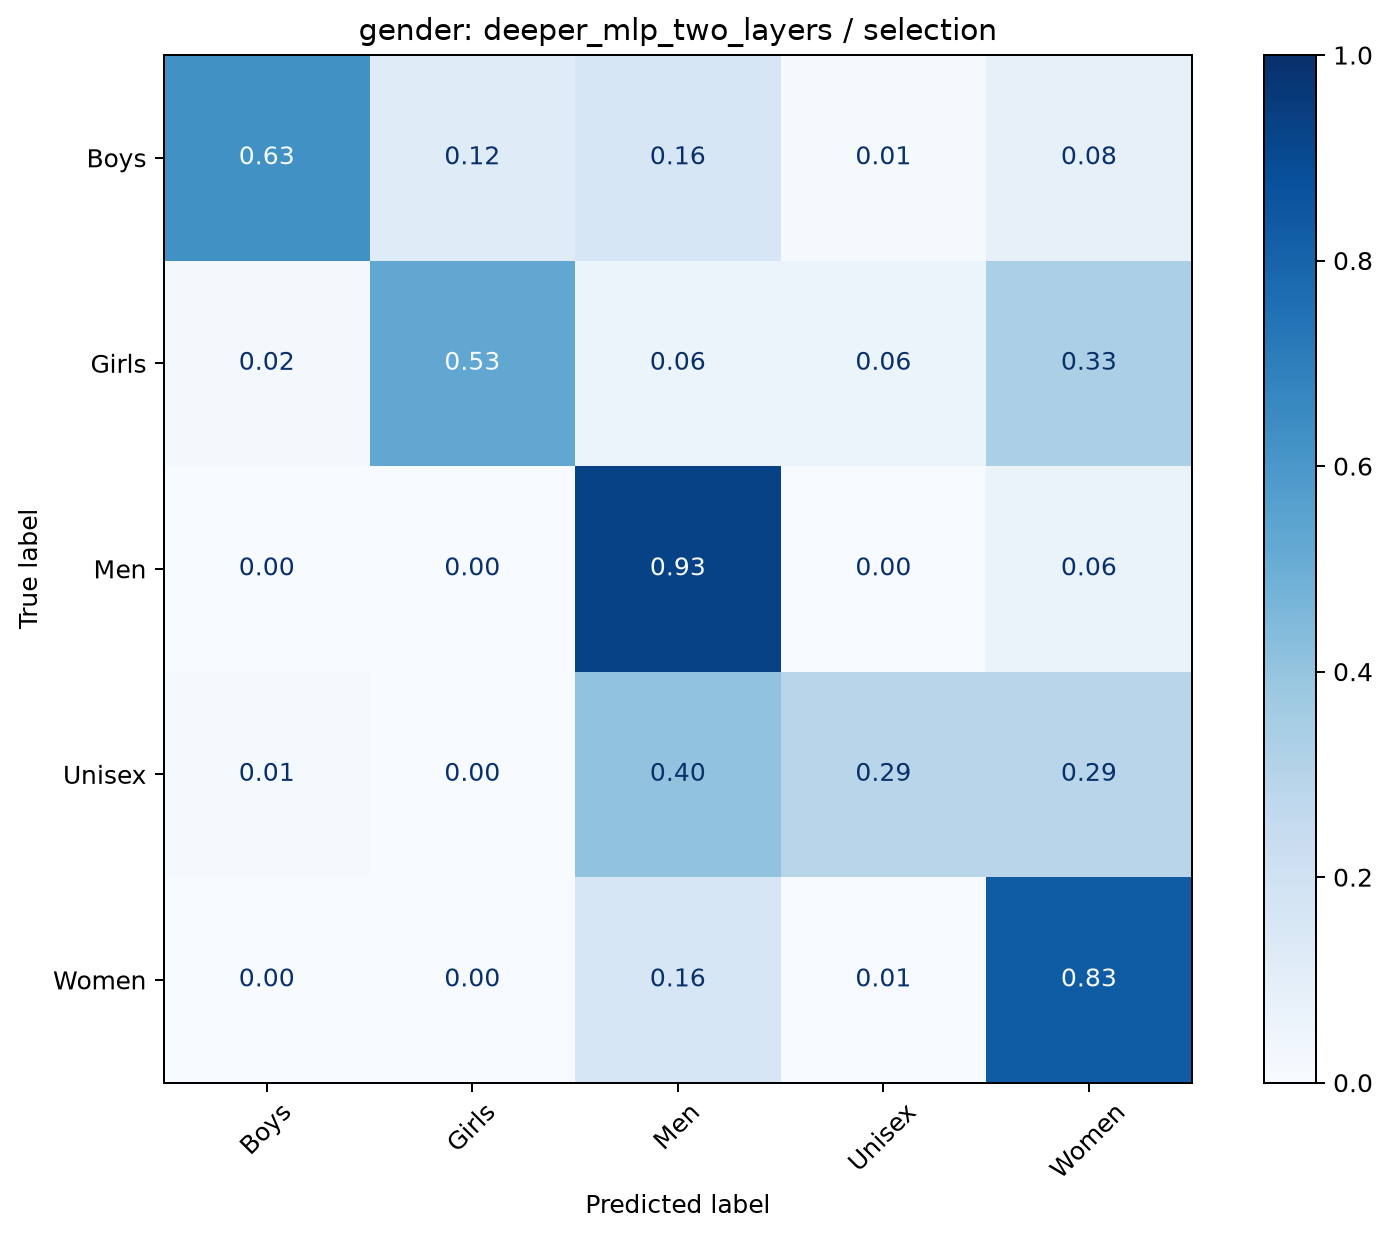

In [ ]:
# Plot this model's selection matrix using the predictions calculated above.
labels = labels_by_target['gender']
counts = pd.DataFrame(
    tf.math.confusion_matrix(loader.targets, predictions, num_classes=len(labels)).numpy(),
    index=labels, columns=labels,
)
plot_confusion_figure(
    counts, 'gender', f'gender: {method} / selection',
)


#### 5.2.4. Gender: Evaluation Analysis

Deeper MLP: 84.52% selection accuracy, 0.6912 supported-class macro-F1, 9,470,981 parameters. The best macro-F1 epoch was 18 out of 20 in the training run. The training accuracy at that epoch was 84.07%, the training loss was 0.4479 and the selection loss was 0.4664. The small difference in accuracy provides little evidence of severe overfitting. The two evaluation conditions are not equivalent due to dropout and training-only augmentation.

Men precision 0.862, recall 0.929, F1 0.895 (n=1612); Women precision 0.830, recall 0.831, F1 0.830 (n=1001); Boys precision 0.887, recall 0.627, F1 0.734 (n=75); Girls precision 0.643, recall 0.529, F1 0.581 (n=51); Unisex precision 0.723, recall 0.292, F1 0.416 (n=161). 0 classes with no recall out of 5 represented classes. The macro-F1 supported-class does not consider classes not included in this partition. 

The dense model compares on flattened pixels, but does not beat the CNN on selection macro-F1. Additional depth does not, in itself, mean better generalization. These results characterize this completed run; broader claims are constrained by minority support and a single random seed.

#### 5.2.5. Occasion: Model Architecture & Training Configuration

Configuration `deeper_mlp`; hidden dense units [256, 128, 64]. Adam 0.001, maximum 30 epochs, early-stopping patience 7.

In [21]:
# Build the deeper MLP from the selected target-specific configuration.
config = SELECTED_CONFIGS['usage']['deeper_mlp']
method = config['method']
keras.utils.set_random_seed(SEED)

# Start with a fixed image input and training-only horizontal augmentation.
layers = [
    keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)),
    keras.layers.RandomFlip('horizontal'),
]
layers.append(keras.layers.Flatten())

# Add the configured hidden classifier layers and dropout regularization.
for width in config['widths']:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['usage'])), ModelMetadata(name='metadata')])
models['usage'][method] = keras.Sequential(layers, name=method)
models['usage'][method].summary()

Model: "deeper_mlp"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_3 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 36864)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 256)            │     9,437,440 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 9)              │           585 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ metadata (ModelMetadata)        │ (None, 9)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,479,177 (36.16 MB)

 Trainable params: 9,479,177 (36.16 MB)

 Non-trainable params: 0 (0.00 B)

#### 5.2.6. Occasion: Compile & Train Model

The selection view controls epoch selection. Test images are excluded from training.

In [22]:
# Compile and train the model while restoring the epoch with the best selection macro-F1.
model = models['usage'][method]

# Configure optimization and report both accuracy and imbalance-aware macro-F1.
model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['usage'])),
    ],
)
loaders['usage']['train'].reset()

# Stop when selection macro-F1 no longer improves and restore its best weights.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True
    )
]

# Keep the selection partition read-only: it chooses epochs but never updates weights.
fitted = model.fit(
    loaders['usage']['train'],
    validation_data=loaders['usage']['selection'],
    epochs=30,
    callbacks=callbacks,
    shuffle=False,
    verbose=2,
)
histories['usage'][method] = pd.DataFrame(fitted.history)

Epoch 1/30


423/423 - 12s - 29ms/step - accuracy: 0.7261 - loss: 1.2949 - macro_f1: 0.1795 - val_accuracy: 0.8110 - val_loss: 0.6401 - val_macro_f1: 0.2797


Epoch 2/30


423/423 - 11s - 27ms/step - accuracy: 0.7949 - loss: 0.7086 - macro_f1: 0.2266 - val_accuracy: 0.8255 - val_loss: 0.5570 - val_macro_f1: 0.2896


Epoch 3/30


...

423/423 - 11s - 27ms/step - accuracy: 0.8526 - loss: 0.4481 - macro_f1: 0.3074 - val_accuracy: 0.8566 - val_loss: 0.4372 - val_macro_f1: 0.3441


Epoch 17/30


423/423 - 12s - 29ms/step - accuracy: 0.8546 - loss: 0.4387 - macro_f1: 0.3102 - val_accuracy: 0.8552 - val_loss: 0.4318 - val_macro_f1: 0.3453


Epoch 18/30


423/423 - 11s - 27ms/step - accuracy: 0.8548 - loss: 0.4350 - macro_f1: 0.3092 - val_accuracy: 0.8614 - val_loss: 0.4369 - val_macro_f1: 0.3585


#### 5.2.7. Occasion: Evaluation and Performance Metrics

Calculate validation accuracy and supported-class macro-F1, display the per-class classification report, and plot training and validation loss, accuracy and macro-F1. These measurements use the restored best epoch.

selection_accuracy    0.856207
selection_macro_f1    0.359960
dtype: float64

,precision,recall,f1-score,support
Casual,0.878838,0.946804,0.911556,2237.000000
Ethnic,0.651961,0.801205,0.718919,166.000000
Formal,0.861314,0.662921,0.749206,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.765101,0.371336,0.500000,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.856207,0.856207,0.856207,0.856207


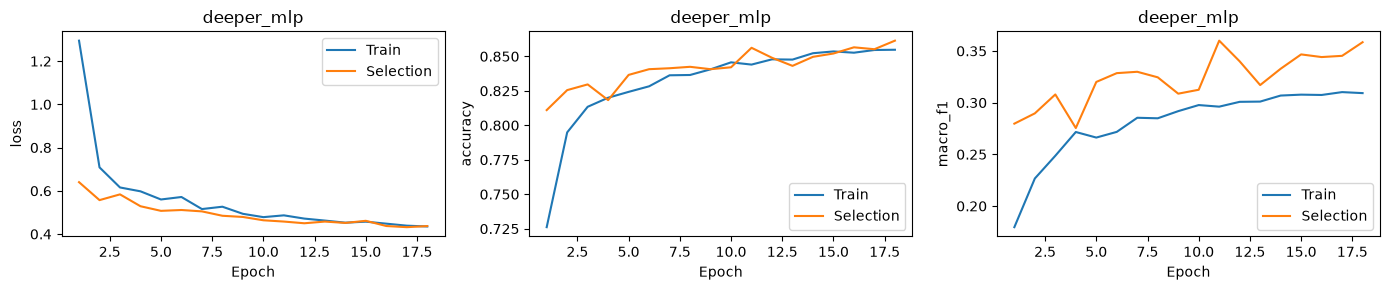

In [ ]:
# Evaluate the restored best weights, show class metrics, and plot the learning curves.
loader = loaders['usage']['selection']

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(models['usage'][method](loader[i][0], training=False)).numpy()
        for i in range(len(loader))
    ]
)
predictions = probabilities.argmax(1)
display(
    pd.Series(
        dict(
            selection_accuracy=accuracy_score(loader.targets, predictions),
            selection_macro_f1=f1_score(
                loader.targets,
                predictions,
                labels=np.unique(loader.targets),
                average='macro',
                zero_division=0,
            ),
        )
    )
)

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        loader.targets,
        predictions,
        labels=np.arange(len(labels_by_target['usage'])),
        target_names=labels_by_target['usage'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / f"{stem_for('usage')}_{method}_selection_per_class.csv")

# Plot train and selection curves to diagnose convergence and overfitting.
history = histories['usage'][method]
history.to_csv(RESULTS / f"{stem_for('usage')}_{method}_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
    ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
    ax.plot(np.arange(1, len(history) + 1), history['val_' + metric], label='Selection')
    ax.set(xlabel='Epoch', ylabel=metric, title=method)
    ax.legend()
fig.tight_layout()
plt.show()

# Store one comparable row for the final cross-family decision.
selection_scores.setdefault('usage', {})[method] = dict(
    family='deeper_mlp',
    validation_accuracy=accuracy_score(loader.targets, predictions),
    validation_macro_f1=f1_score(
        loader.targets,
        predictions,
        labels=np.unique(loader.targets),
        average='macro',
        zero_division=0,
    ),
    complexity_parameters=models['usage'][method].count_params(),
    epochs_run=len(history),
)

In [ ]:
# Plot this model's selection matrix using the predictions calculated above.
labels = labels_by_target['usage']
counts = pd.DataFrame(
    tf.math.confusion_matrix(loader.targets, predictions, num_classes=len(labels)).numpy(),
    index=labels, columns=labels,
)
plot_confusion_figure(
    counts, 'usage', f'usage: {method} / selection',
)

Confusion image unavailable for this evaluated run: the saved experimental occasion deeper-MLP checkpoint scores 86.55%, while this notebook reports 85.62%. Matching predictions or a matching checkpoint are needed.

#### 5.2.8. Occasion: Evaluation Analysis

The Deeper MLP achieved 85.62% selection accuracy and 0.3600 supported-class macro-F1 with 9,479,177 parameters. The best epoch for macro-F1 was 11 of 18 in the training run. At that epoch, training accuracy was 84.40% , training loss was 0.4865 and selection loss was 0.4577 . The small gap in accuracy shows little evidence of severe overfitting. Dropout and augmentation only during training lead to different evaluation conditions.

Casual: precision 0.879 recall 0.947 F1 0.912 (n=2237) Ethnic: precision 0.652 recall 0.801 F1 0.719 (n=166) Formal: precision 0.861 recall 0.663 F1 0.749 (n=178) Sports: precision 0.765 recall 0.371 F1 0.500 (n=307) NA: precision 0.000 recall 0.000 F1 0.000 (n=5) Recall for 4 of 8 classes represented was zero. The supported-class macro-F1 does not consider classes that are not in this partition. Party, Smart Casual and Travel have only one, four and two examples respectively and none is recovered. The literal NA is a label for a data set, not a blank value. 

The dense model offers a comparison with flat pixels but it does not outperform the CNN in terms of selection macro-F1. Additional depth does not, in itself, mean better generalization. These results characterize this completed run; broader claims are constrained by minority support and a single random seed.

### 5.3. Convolutional Neural Network (CNN)

The selected CNN uses four 3x3 convolution blocks (32, 64, 128, 256 filters), batch normalization, ReLU and max pooling, followed by a 2x2 pooled grid and Dense(256). Only the selected continuation, when required, is fitted.

#### 5.3.1. Gender: Model Architecture & Training Configuration

Configuration `cnn_four_blocks_scheduled`; hidden dense units [256]. Initial Adam 0.001, maximum 30 epochs, early-stopping patience 7 and learning-rate halving after two unimproved epochs. Continuation, if specified, uses eight additional epochs with patience 4 and a fresh optimizer.

In [24]:
# Build the CNN from the selected target-specific configuration.
config = SELECTED_CONFIGS['gender']['cnn']
method = config['method']
keras.utils.set_random_seed(SEED)

# Start with a fixed image input and training-only horizontal augmentation.
layers = [
    keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)),
    keras.layers.RandomFlip('horizontal'),
]

# Learn increasingly abstract local features while reducing spatial resolution.
for width in [32, 64, 128, 256]:
    layers.extend(
        [
            keras.layers.Conv2D(width, 3, padding='same'),
            keras.layers.BatchNormalization(),
            keras.layers.Activation('relu'),
            keras.layers.MaxPooling2D(2),
        ]
    )
h, w = IMAGE_SIZE[1] // 16, IMAGE_SIZE[0] // 16
layers.extend([keras.layers.AveragePooling2D((h // 2, w // 2)), keras.layers.Flatten()])

# Add the configured hidden classifier layers and dropout regularization.
for width in config['widths']:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['gender'])), ModelMetadata(name='metadata')])
models['gender'][method] = keras.Sequential(layers, name=method)
models['gender'][method].summary()

Model: "cnn_four_blocks_scheduled"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_4 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 16, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 16, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d               │ (None, 2, 2, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 5)              │         1,285 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 654,021 (2.49 MB)

 Trainable params: 653,061 (2.49 MB)

 Non-trainable params: 960 (3.75 KB)

#### 5.3.2. Gender: Compile & Train Model

The selection view controls epoch selection. Test images are excluded from training.

In [25]:
# Compile and train the model while restoring the epoch with the best selection macro-F1.
model = models['gender'][method]

# Configure optimization and report both accuracy and imbalance-aware macro-F1.
model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['gender'])),
    ],
)
loaders['gender']['train'].reset()

# Stop when selection macro-F1 no longer improves and restore its best weights.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True
    )
]
callbacks.insert(
    0, keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2)
)

# Keep the selection partition read-only: it chooses epochs but never updates weights.
fitted = model.fit(
    loaders['gender']['train'],
    validation_data=loaders['gender']['selection'],
    epochs=30,
    callbacks=callbacks,
    shuffle=False,
    verbose=2,
)
histories['gender'][method] = pd.DataFrame(fitted.history)

Epoch 1/30


2026-09-12 01:58:52.690772: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:473] Loaded cuDNN version 92501


423/423 - 28s - 66ms/step - accuracy: 0.7518 - loss: 0.6594 - macro_f1: 0.3848 - val_accuracy: 0.7848 - val_loss: 0.5613 - val_macro_f1: 0.4844 - learning_rate: 0.0010


Epoch 2/30


423/423 - 26s - 61ms/step - accuracy: 0.8186 - loss: 0.4892 - macro_f1: 0.5522 - val_accuracy: 0.8059 - val_loss: 0.5249 - val_macro_f1: 0.5640 - learning_rate: 0.0010


...

423/423 - 26s - 62ms/step - accuracy: 0.9490 - loss: 0.1463 - macro_f1: 0.8818 - val_accuracy: 0.9003 - val_loss: 0.3262 - val_macro_f1: 0.7860 - learning_rate: 6.2500e-05


Epoch 19/30


423/423 - 25s - 60ms/step - accuracy: 0.9499 - loss: 0.1414 - macro_f1: 0.8820 - val_accuracy: 0.9007 - val_loss: 0.3274 - val_macro_f1: 0.7710 - learning_rate: 6.2500e-05


Epoch 20/30


423/423 - 26s - 61ms/step - accuracy: 0.9558 - loss: 0.1309 - macro_f1: 0.9013 - val_accuracy: 0.9031 - val_loss: 0.3272 - val_macro_f1: 0.7838 - learning_rate: 3.1250e-05


#### 5.3.3. Gender: Evaluation and Performance Metrics

Calculate validation accuracy and supported-class macro-F1, display the per-class classification report, and plot training and validation loss, accuracy and macro-F1. These measurements use the restored best epoch.

selection_accuracy    0.899310
selection_macro_f1    0.790123
dtype: float64

,precision,recall,f1-score,support
Boys,0.791667,0.760000,0.775510,75.00000
Girls,0.650794,0.803922,0.719298,51.00000
Men,0.914868,0.946650,0.930488,1612.00000
Unisex,0.735043,0.534161,0.618705,161.00000
Women,0.916327,0.897103,0.906613,1001.00000
accuracy,0.899310,0.899310,0.899310,0.89931
macro avg,0.801740,0.788367,0.790123,2900.00000
weighted avg,0.897558,0.899310,0.897215,2900.00000


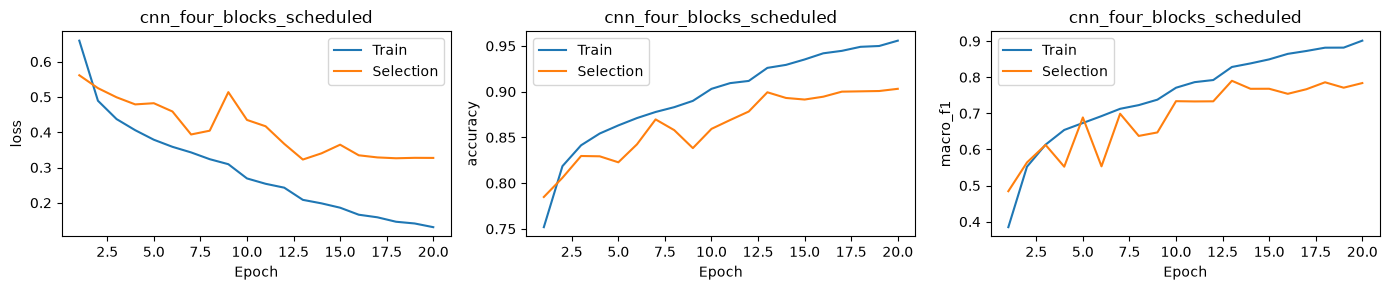

In [ ]:
# Evaluate the restored best weights, show class metrics, and plot the learning curves.
loader = loaders['gender']['selection']

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(models['gender'][method](loader[i][0], training=False)).numpy()
        for i in range(len(loader))
    ]
)
predictions = probabilities.argmax(1)
display(
    pd.Series(
        dict(
            selection_accuracy=accuracy_score(loader.targets, predictions),
            selection_macro_f1=f1_score(
                loader.targets,
                predictions,
                labels=np.unique(loader.targets),
                average='macro',
                zero_division=0,
            ),
        )
    )
)

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        loader.targets,
        predictions,
        labels=np.arange(len(labels_by_target['gender'])),
        target_names=labels_by_target['gender'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / f"{stem_for('gender')}_{method}_selection_per_class.csv")

# Plot train and selection curves to diagnose convergence and overfitting.
history = histories['gender'][method]
history.to_csv(RESULTS / f"{stem_for('gender')}_{method}_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
    ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
    ax.plot(np.arange(1, len(history) + 1), history['val_' + metric], label='Selection')
    ax.set(xlabel='Epoch', ylabel=metric, title=method)
    ax.legend()
fig.tight_layout()
plt.show()

# Store one comparable row for the final cross-family decision.
selection_scores.setdefault('gender', {})[method] = dict(
    family='cnn',
    validation_accuracy=accuracy_score(loader.targets, predictions),
    validation_macro_f1=f1_score(
        loader.targets,
        predictions,
        labels=np.unique(loader.targets),
        average='macro',
        zero_division=0,
    ),
    complexity_parameters=models['gender'][method].count_params(),
    epochs_run=len(history),
)

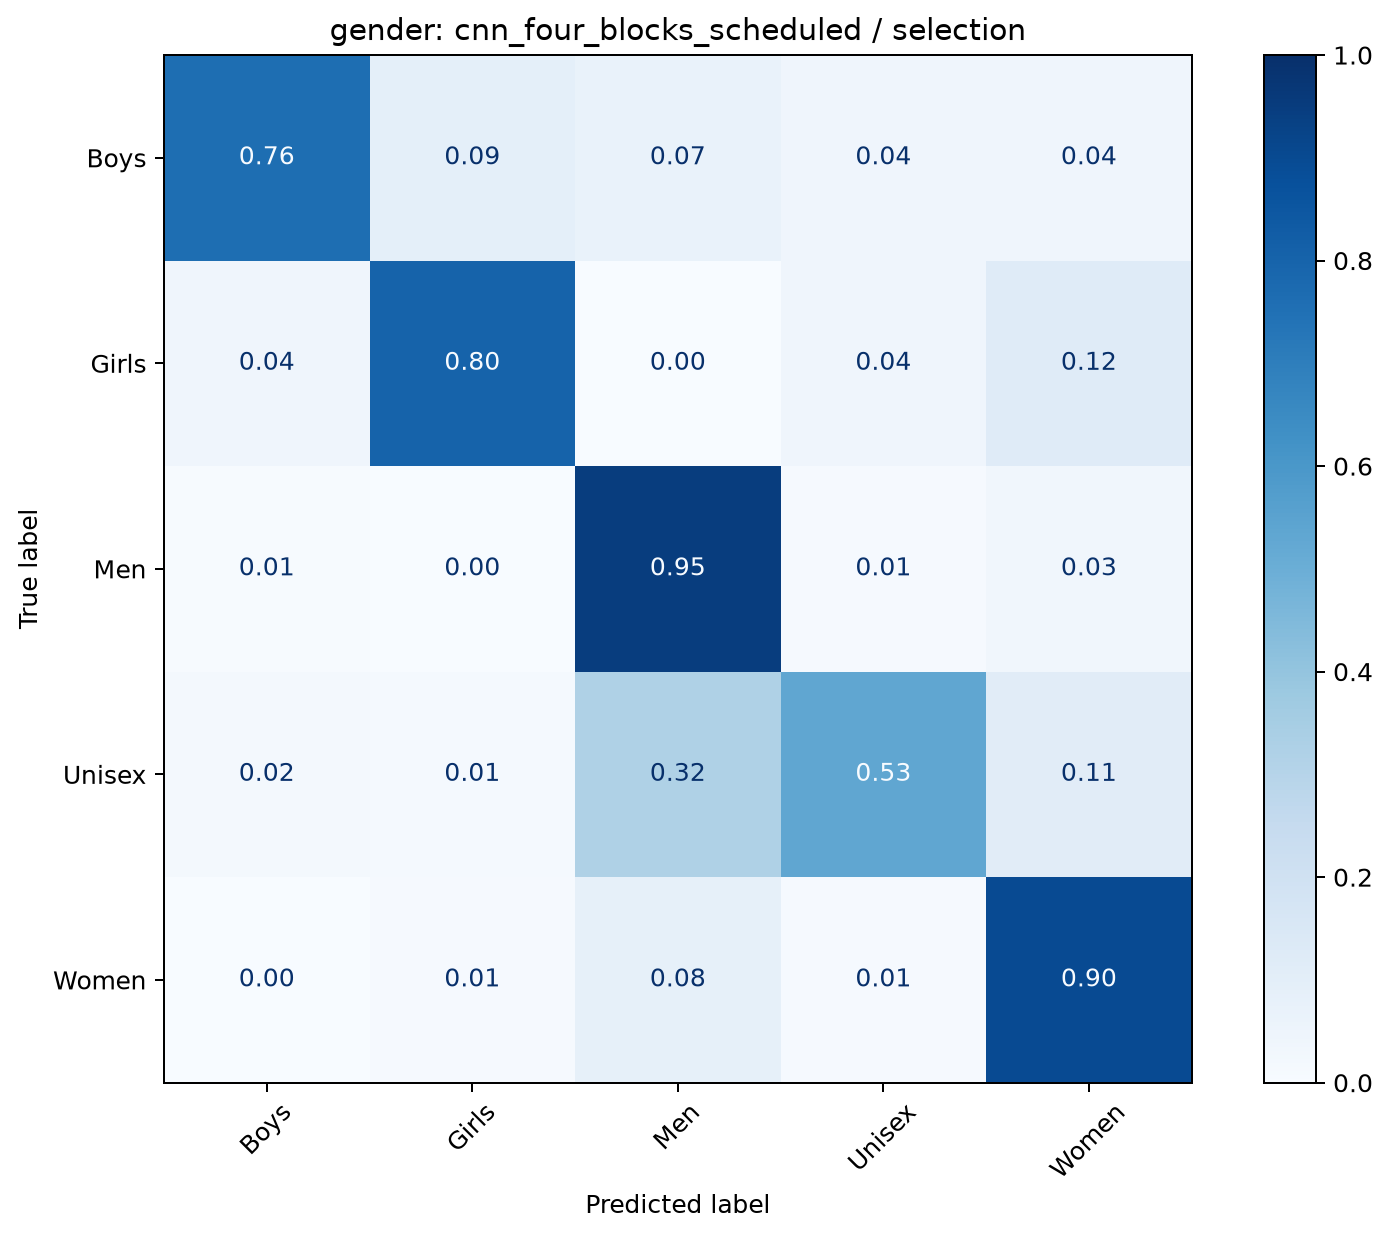

In [ ]:
# Plot this model's selection matrix using the predictions calculated above.
labels = labels_by_target['gender']
counts = pd.DataFrame(
    tf.math.confusion_matrix(loader.targets, predictions, num_classes=len(labels)).numpy(),
    index=labels, columns=labels,
)
plot_confusion_figure(
    counts, 'gender', f'gender: {method} / selection',
)

#### 5.3.4. Gender: Evaluation Analysis

The CNN achieved a selection accuracy of 89.93% and supported-class macro-F1 of 0.7901 with 654,021 parameters. epoch 13 out of 20 in the training run was the best macro-F1 epoch The training accuracy for this epoch was 92.60% and the training and selection losses were 0.2083 and 0.3225, respectively. The difference in accuracy shows some overfitting . The checkpoint to restore is selected based on selection performance not training accuracy .

Men precision 0.915, recall 0.947 and F1 0.930 (n=1612) Women precision 0.916, recall 0.897 and F1 0.907 (n=1001) Boys precision 0.792, recall 0.760 and F1 0.776 (n=75) Girls precision 0.651, recall 0.804 and F1 0.719 (n=51) Unisex precision 0.735, recall 0.534 and F1 0.619 (n=161). For the 5 classes represented, 0 have zero recall. The supported-class macro-F1 excludes classes that are not included in this partition. 

This CNN wins the announced selection rule and is exported as the final classifier. Convolution preserves the local image relationships, and provides a more efficient representation than the flattened dense models. These results characterize this completed run, minority support and a single random seed constrain broader claims.

#### 5.3.5. Occasion: Model Architecture & Training Configuration

Configuration `cnn_continue_weighted`; hidden dense units [256]. Initial Adam 0.001, maximum 30 epochs, early-stopping patience 7 and learning-rate halving after two unimproved epochs. Continuation, if specified, uses eight additional epochs with patience 4 and a fresh optimizer.

In [27]:
# Build the CNN from the selected target-specific configuration.
config = SELECTED_CONFIGS['usage']['cnn']
method = config['method']
keras.utils.set_random_seed(SEED)

# Start with a fixed image input and training-only horizontal augmentation.
layers = [
    keras.Input(shape=(IMAGE_SIZE[1], IMAGE_SIZE[0], 3)),
    keras.layers.RandomFlip('horizontal'),
]

# Learn increasingly abstract local features while reducing spatial resolution.
for width in [32, 64, 128, 256]:
    layers.extend(
        [
            keras.layers.Conv2D(width, 3, padding='same'),
            keras.layers.BatchNormalization(),
            keras.layers.Activation('relu'),
            keras.layers.MaxPooling2D(2),
        ]
    )
h, w = IMAGE_SIZE[1] // 16, IMAGE_SIZE[0] // 16
layers.extend([keras.layers.AveragePooling2D((h // 2, w // 2)), keras.layers.Flatten()])

# Add the configured hidden classifier layers and dropout regularization.
for width in config['widths']:
    layers.extend([keras.layers.Dense(width, activation='relu'), keras.layers.Dropout(0.2)])
layers.extend([keras.layers.Dense(len(labels_by_target['usage'])), ModelMetadata(name='metadata')])
models['usage'][method] = keras.Sequential(layers, name=method)
models['usage'][method].summary()

Model: "cnn_continue_weighted"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip_5 (RandomFlip)      │ (None, 128, 96, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 128, 96, 32)    │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128, 96, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_4 (Activation)       │ (None, 128, 96, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 64, 48, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 64, 48, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 64, 48, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_5 (Activation)       │ (None, 64, 48, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 32, 24, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 24, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 32, 24, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 32, 24, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 12, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 16, 12, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 16, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 6, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling2d_1             │ (None, 2, 2, 256)      │             0 │
│ (AveragePooling2D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 9)              │         2,313 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 655,049 (2.50 MB)

 Trainable params: 654,089 (2.50 MB)

 Non-trainable params: 960 (3.75 KB)

#### 5.3.6. Occasion: Compile & Train Model

The selection view controls epoch selection. Test images are excluded from training.

In [28]:
# Compile and train the model while restoring the epoch with the best selection macro-F1.
model = models['usage'][method]

# Configure optimization and report both accuracy and imbalance-aware macro-F1.
model.compile(
    optimizer=keras.optimizers.Adam(0.001),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['usage'])),
    ],
)
loaders['usage']['train'].reset()

# Stop when selection macro-F1 no longer improves and restore its best weights.
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_macro_f1', mode='max', patience=7, restore_best_weights=True
    )
]
callbacks.insert(
    0, keras.callbacks.ReduceLROnPlateau(monitor='val_macro_f1', mode='max', factor=0.5, patience=2)
)

# Keep the selection partition read-only: it chooses epochs but never updates weights.
fitted = model.fit(
    loaders['usage']['train'],
    validation_data=loaders['usage']['selection'],
    epochs=30,
    callbacks=callbacks,
    shuffle=False,
    verbose=2,
)
histories['usage'][method] = pd.DataFrame(fitted.history)
histories['usage'][method].to_csv(RESULTS / 'usage_cnn_initial_history.csv', index=False)

# Begin the low-learning-rate continuation from the initial CNN weights.
# Reset the loader so continuation starts from a reproducible order.
keras.utils.set_random_seed(SEED)
loaders['usage']['train'].reset()
model.compile(
    optimizer=keras.optimizers.Adam(3e-05),
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    metrics=[
        keras.metrics.SparseCategoricalAccuracy(name='accuracy'),
        SupportedMacroF1(len(labels_by_target['usage'])),
    ],
)
class_weight = None

# Use capped square-root class weights to help rare labels without destabilizing training.
counts = np.bincount(loaders['usage']['train'].targets, minlength=len(labels_by_target['usage']))
weights = np.sqrt(counts.sum() / (len(counts) * counts))
weights = np.clip(weights / np.average(weights, weights=counts), 0.25, 6)
class_weight = dict(enumerate(weights))
fitted = model.fit(
    loaders['usage']['train'],
    validation_data=loaders['usage']['selection'],
    epochs=8,
    callbacks=[
        keras.callbacks.EarlyStopping(
            monitor='val_macro_f1', mode='max', patience=4, restore_best_weights=True
        )
    ],
    class_weight=class_weight,
    shuffle=False,
    verbose=2,
)
histories['usage'][method] = pd.DataFrame(fitted.history)

Epoch 1/30


423/423 - 28s - 65ms/step - accuracy: 0.8059 - loss: 0.5992 - macro_f1: 0.2303 - val_accuracy: 0.8166 - val_loss: 0.5304 - val_macro_f1: 0.2508 - learning_rate: 0.0010


Epoch 2/30


423/423 - 25s - 60ms/step - accuracy: 0.8379 - loss: 0.4696 - macro_f1: 0.2872 - val_accuracy: 0.8334 - val_loss: 0.4864 - val_macro_f1: 0.3103 - learning_rate: 0.0010


Epoch 3/30


...

423/423 - 25s - 59ms/step - accuracy: 0.9501 - loss: 0.1921 - macro_f1: 0.5432 - val_accuracy: 0.8841 - val_loss: 0.3410 - val_macro_f1: 0.4449


Epoch 5/8


423/423 - 25s - 60ms/step - accuracy: 0.9488 - loss: 0.1895 - macro_f1: 0.5156 - val_accuracy: 0.8803 - val_loss: 0.3470 - val_macro_f1: 0.4443


Epoch 6/8


423/423 - 25s - 59ms/step - accuracy: 0.9496 - loss: 0.1873 - macro_f1: 0.5568 - val_accuracy: 0.8907 - val_loss: 0.3214 - val_macro_f1: 0.4472


#### 5.3.7. Occasion: Evaluation and Performance Metrics

Calculate validation accuracy and supported-class macro-F1, display the per-class classification report, and plot training and validation loss, accuracy and macro-F1. These measurements use the restored best epoch.

selection_accuracy    0.894483
selection_macro_f1    0.454306
dtype: float64

,precision,recall,f1-score,support
Casual,0.937698,0.928476,0.933064,2237.000000
Ethnic,0.796875,0.921687,0.854749,166.000000
Formal,0.801105,0.814607,0.807799,178.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,1.000000,0.200000,0.333333,5.000000
Party,0.000000,0.000000,0.000000,1.000000
Smart Casual,0.000000,0.000000,0.000000,4.000000
Sports,0.700965,0.710098,0.705502,307.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.894483,0.894483,0.894483,0.894483


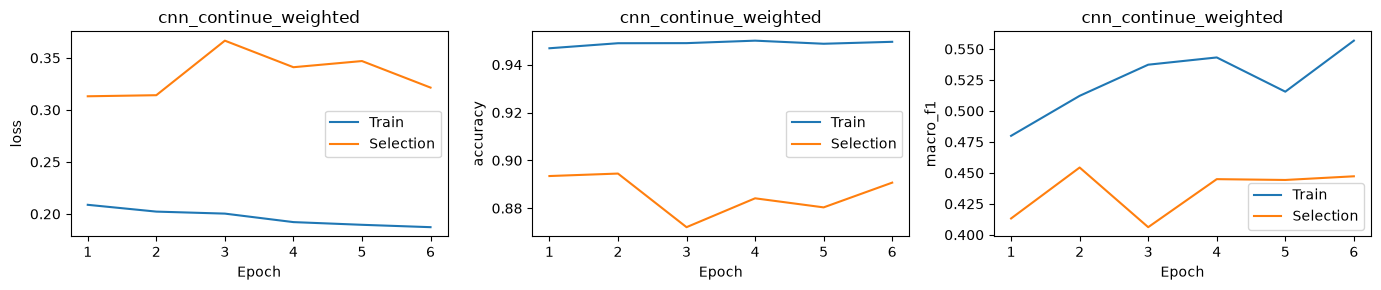

In [ ]:
# Evaluate the restored best weights, show class metrics, and plot the learning curves.
loader = loaders['usage']['selection']

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(models['usage'][method](loader[i][0], training=False)).numpy()
        for i in range(len(loader))
    ]
)
predictions = probabilities.argmax(1)
display(
    pd.Series(
        dict(
            selection_accuracy=accuracy_score(loader.targets, predictions),
            selection_macro_f1=f1_score(
                loader.targets,
                predictions,
                labels=np.unique(loader.targets),
                average='macro',
                zero_division=0,
            ),
        )
    )
)

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        loader.targets,
        predictions,
        labels=np.arange(len(labels_by_target['usage'])),
        target_names=labels_by_target['usage'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / f"{stem_for('usage')}_{method}_selection_per_class.csv")

# Plot train and selection curves to diagnose convergence and overfitting.
history = histories['usage'][method]
history.to_csv(RESULTS / f"{stem_for('usage')}_{method}_history.csv", index=False)
fig, axes = plt.subplots(1, 3, figsize=(14, 3))
for ax, metric in zip(axes, ['loss', 'accuracy', 'macro_f1']):
    ax.plot(np.arange(1, len(history) + 1), history[metric], label='Train')
    ax.plot(np.arange(1, len(history) + 1), history['val_' + metric], label='Selection')
    ax.set(xlabel='Epoch', ylabel=metric, title=method)
    ax.legend()
fig.tight_layout()
plt.show()

# Store one comparable row for the final cross-family decision.
selection_scores.setdefault('usage', {})[method] = dict(
    family='cnn',
    validation_accuracy=accuracy_score(loader.targets, predictions),
    validation_macro_f1=f1_score(
        loader.targets,
        predictions,
        labels=np.unique(loader.targets),
        average='macro',
        zero_division=0,
    ),
    complexity_parameters=models['usage'][method].count_params(),
    epochs_run=len(history),
)

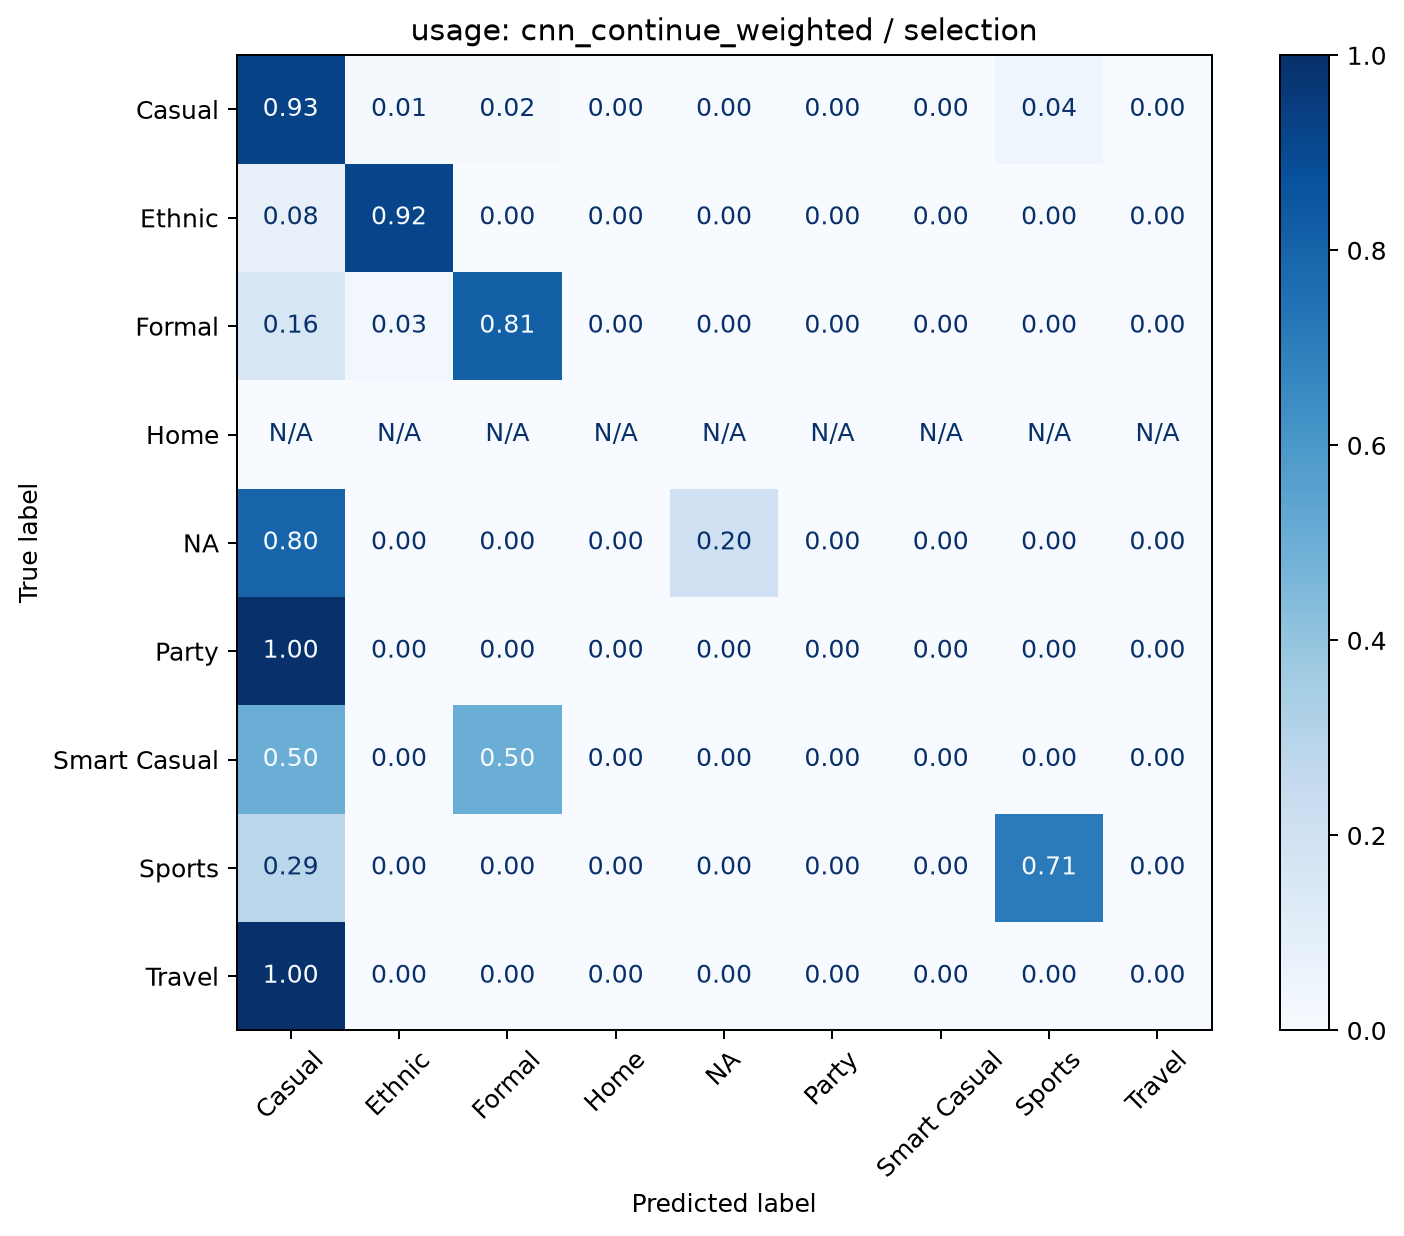

In [ ]:
# Plot this model's selection matrix using the predictions calculated above.
labels = labels_by_target['usage']
counts = pd.DataFrame(
    tf.math.confusion_matrix(loader.targets, predictions, num_classes=len(labels)).numpy(),
    index=labels, columns=labels,
)
plot_confusion_figure(
    counts, 'usage', f'usage: {method} / selection',
)


#### 5.3.8. Occasion: Evaluation Analysis

The CNN achieved 89.45% selection accuracy and 0.4543 supported-class macro-F1 with 655,049 parameters. In the continuation stage, the best macro-F1 epoch was 2 out of 6 epochs. The training accuracy at that epoch was 94.90% , with a training loss of 0.2022, and a selection loss of 0.3141. The accuracy gap shows some overfitting, and the selection performance, not the training accuracy, dictates which checkpoint to restore. The class-weighted training loss cannot be directly compared to the unweighted selection loss.

Casual has precision of 0.938, recall of 0.928 and F1 of 0.933 (n=2237) Ethnic has precision of 0.797, recall of 0.922 and F1 of 0.855 (n=166) Formal has precision of 0.801, recall of 0.815 and F1 of 0.808 (n=178) Sports has precision of 0.701, recall of 0.710 and F1 of 0.706 (n=307) NA has precision of 1.000, recall of 0.200 and F1 of 0.333 (n=5). There is no recall for 3 of the 8 classes represented. Classes not appearing in this partition are excluded from the supported-class macro-F1. Party, Smart Casual and Travel have only one, four and two examples respectively and none is recovered. Literal NA is a label in the dataset, not a missing value. 

This CNN is the winner of the announced selection rule and exported as the final classifier. The convolution operation maintains the local relationships of the image and provides a more compact representation than flattened dense models. The macro-F1 improvement over the shallow baseline is just 0.0021, indicating that the ranking is still sensitive to sparse classes despite higher accuracy. Minority support, and a single random seed, do not permit broader claims; these results describe this particular run.

## 6. Ultimate Judgement

The three model families are compared using the validation metrics already calculated in their evaluation sections. The model with the highest validation macro-F1 is selected. Accuracy and parameter count are used to interpret the result and would break an exact macro-F1 tie.

In [30]:
# Prepare containers for the cross-family comparison and final checkpoints.
comparisons, winners, checkpoints = {}, {}, {}

In [31]:
# Rank the three model families by macro-F1, then accuracy, then parameter count.
comparison = pd.DataFrame(selection_scores['gender']).T
comparison = comparison.sort_values(
    ['validation_macro_f1', 'validation_accuracy', 'complexity_parameters'],
    ascending=[False, False, True],
)
winners['gender'] = comparison.index[0]
comparison['selected'] = comparison.index == winners['gender']
comparisons['gender'] = comparison
display(comparison)
print('Selected:', winners['gender'])
comparison.to_csv(RESULTS / 'gender_comparison.csv')

,family,validation_accuracy,validation_macro_f1,complexity_parameters,epochs_run,selected
cnn_four_blocks_scheduled,cnn,0.89931,0.790123,654021,20,True
shallow_mlp_lower_lr,shallow_mlp,0.846897,0.711753,9438725,12,False
deeper_mlp_two_layers,deeper_mlp,0.845172,0.691177,9470981,20,False


Selected: cnn_four_blocks_scheduled


**Model comparison: gender**

| Family | Configuration | Selection accuracy | Macro-F1 | Parameters |
|---|---|---:|---:|---:|
| Shallow MLP | shallow_mlp_lower_lr | 84.69% | 0.7118 | 9,438,725 |
| Deeper MLP | deeper_mlp_two_layers | 84.52% | 0.6912 | 9,470,981 |
| CNN | cnn_four_blocks_scheduled | 89.93% | 0.7901 | 654,021 |

In [32]:
# Rank the three model families by macro-F1, then accuracy, then parameter count.
comparison = pd.DataFrame(selection_scores['usage']).T
comparison = comparison.sort_values(
    ['validation_macro_f1', 'validation_accuracy', 'complexity_parameters'],
    ascending=[False, False, True],
)
winners['usage'] = comparison.index[0]
comparison['selected'] = comparison.index == winners['usage']
comparisons['usage'] = comparison
display(comparison)
print('Selected:', winners['usage'])
comparison.to_csv(RESULTS / 'usage_comparison.csv')

,family,validation_accuracy,validation_macro_f1,complexity_parameters,epochs_run,selected
cnn_continue_weighted,cnn,0.894483,0.454306,655049,6,True
shallow_mlp_lower_lr,shallow_mlp,0.873793,0.452185,9439753,14,False
deeper_mlp,deeper_mlp,0.856207,0.35996,9479177,18,False


Selected: cnn_continue_weighted


**Model comparison: usage**

| Family | Configuration | Selection accuracy | Macro-F1 | Parameters |
|---|---|---:|---:|---:|
| Shallow MLP | shallow_mlp_lower_lr | 87.38% | 0.4522 | 9,439,753 |
| Deeper MLP | deeper_mlp | 85.62% | 0.3600 | 9,479,177 |
| CNN | cnn_continue_weighted | 89.45% | 0.4543 | 655,049 |

In [33]:
# Define imbalance-aware performance and probability-calibration metrics for the final test.
def supported_macro_f1(truth, predictions) -> float:
    """Macro-average over labels present in the ground-truth partition."""
    return float(
        f1_score(truth, predictions, labels=np.unique(truth), average="macro", zero_division=0)
    )


def expected_calibration_error(
    truth: np.ndarray,
    probabilities: np.ndarray,
    bins: int = 10,
) -> float:
    """Compute top-label expected calibration error."""
    truth = np.asarray(truth)
    probabilities = np.asarray(probabilities)
    confidence = probabilities.max(axis=1)
    correct = probabilities.argmax(axis=1) == truth
    edges = np.linspace(0.0, 1.0, bins + 1)
    total = len(truth)
    error = 0.0
    for lower, upper in zip(edges[:-1], edges[1:], strict=True):
        selected = (confidence > lower) & (confidence <= upper)
        if selected.any():
            error += (
                selected.sum()
                / total
                * abs(float(correct[selected].mean()) - float(confidence[selected].mean()))
            )
    return float(error)

### 6.1. Selected-Model Evaluation

Evaluate only the selected model on the internal test partition. This cell reports accuracy, supported-class macro-F1, calibration error, negative log-likelihood, Brier score and a per-class classification report. The internal test has prior development exposure and is not used to revise the selected architecture.

In [34]:
# Evaluate each selected family winner once on the untouched internal-test partition.
test_results = {}
checkpoints = {}

method = winners['gender']
model = models['gender'][method]
test_frame = metadata_by_target['gender'].loc[metadata_by_target['gender']['split'].eq('test')]
test_loader = CachedBatches(
    test_frame, 'gender', labels_by_target['gender'], normalisation, batch_size=BATCH_SIZE
)

# Convert logits to probabilities and preserve the loader's row order.
probabilities = np.vstack(
    [
        tf.nn.softmax(model(test_loader[i][0], training=False)).numpy()
        for i in range(len(test_loader))
    ]
)
truth = test_loader.targets
predictions = probabilities.argmax(1)

# Measure label accuracy, class balance, and probability quality on the final test.
metrics = {
    'accuracy': float(accuracy_score(truth, predictions)),
    'macro_f1': supported_macro_f1(truth, predictions),
    'ece': expected_calibration_error(truth, probabilities),
    'nll': float(log_loss(truth, probabilities, labels=np.arange(len(labels_by_target['gender'])))),
    'brier': float(
        np.mean(
            np.sum((probabilities - np.eye(len(labels_by_target['gender']))[truth]) ** 2, axis=1)
        )
    ),
}
test_results['gender'] = dict(
    labels=labels_by_target['gender'],
    truth=truth,
    predictions=predictions,
    probabilities=probabilities,
    metrics=metrics,
)

# Bundle the fitted model with everything required to reproduce inference.
checkpoints['gender'] = dict(
    target='gender',
    labels=labels_by_target['gender'],
    model=model,
    model_type=method,
    temperature=1.0,
    review_policy=None,
    mean=normalisation['mean'],
    std=normalisation['std'],
    image_size=list(IMAGE_SIZE),
    comparison_row=comparisons['gender'].loc[method].to_dict(),
    test_metrics=metrics,
)
display(pd.Series(metrics, name='gender'))

# Inspect every label because aggregate accuracy can hide minority-class failures.
per_class = pd.DataFrame(
    classification_report(
        truth,
        predictions,
        labels=np.arange(len(labels_by_target['gender'])),
        target_names=labels_by_target['gender'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / 'gender_test_per_class.csv')
pd.Series(metrics).to_csv(RESULTS / 'gender_test_metrics.csv')

method = winners['usage']
model = models['usage'][method]
test_frame = metadata_by_target['usage'].loc[metadata_by_target['usage']['split'].eq('test')]
test_loader = CachedBatches(
    test_frame, 'usage', labels_by_target['usage'], normalisation, batch_size=BATCH_SIZE
)
probabilities = np.vstack(
    [
        tf.nn.softmax(model(test_loader[i][0], training=False)).numpy()
        for i in range(len(test_loader))
    ]
)
truth = test_loader.targets
predictions = probabilities.argmax(1)
metrics = {
    'accuracy': float(accuracy_score(truth, predictions)),
    'macro_f1': supported_macro_f1(truth, predictions),
    'ece': expected_calibration_error(truth, probabilities),
    'nll': float(log_loss(truth, probabilities, labels=np.arange(len(labels_by_target['usage'])))),
    'brier': float(
        np.mean(
            np.sum((probabilities - np.eye(len(labels_by_target['usage']))[truth]) ** 2, axis=1)
        )
    ),
}
test_results['usage'] = dict(
    labels=labels_by_target['usage'],
    truth=truth,
    predictions=predictions,
    probabilities=probabilities,
    metrics=metrics,
)
checkpoints['usage'] = dict(
    target='usage',
    labels=labels_by_target['usage'],
    model=model,
    model_type=method,
    temperature=1.0,
    review_policy=None,
    mean=normalisation['mean'],
    std=normalisation['std'],
    image_size=list(IMAGE_SIZE),
    comparison_row=comparisons['usage'].loc[method].to_dict(),
    test_metrics=metrics,
)
display(pd.Series(metrics, name='usage'))
per_class = pd.DataFrame(
    classification_report(
        truth,
        predictions,
        labels=np.arange(len(labels_by_target['usage'])),
        target_names=labels_by_target['usage'],
        output_dict=True,
        zero_division=0,
    )
).T
display(per_class)
per_class.to_csv(RESULTS / 'usage_test_per_class.csv')
pd.Series(metrics).to_csv(RESULTS / 'usage_test_metrics.csv')

accuracy    0.889122
macro_f1    0.739821
ece         0.021677
nll         0.306724
brier       0.163259
Name: gender, dtype: float64

,precision,recall,f1-score,support
Boys,0.685950,0.638462,0.661355,130.000000
Girls,0.615385,0.648649,0.631579,111.000000
Men,0.904573,0.943702,0.923724,3144.000000
Unisex,0.674107,0.508418,0.579655,297.000000
Women,0.916498,0.889489,0.902792,2036.000000
accuracy,0.889122,0.889122,0.889122,0.889122
macro avg,0.759303,0.725744,0.739821,5718.000000
weighted avg,0.886264,0.889122,0.886763,5718.000000


accuracy    0.895418
macro_f1    0.417098
ece         0.026017
nll         0.317337
brier       0.163401
Name: usage, dtype: float64

,precision,recall,f1-score,support
Casual,0.931802,0.932235,0.932019,4309.000000
Ethnic,0.878995,0.927711,0.902696,415.000000
Formal,0.733333,0.820896,0.774648,335.000000
Home,0.000000,0.000000,0.000000,0.000000
NA,0.000000,0.000000,0.000000,23.000000
Party,0.000000,0.000000,0.000000,2.000000
Smart Casual,0.000000,0.000000,0.000000,7.000000
Sports,0.747049,0.708800,0.727422,625.000000
Travel,0.000000,0.000000,0.000000,2.000000
accuracy,0.895418,0.895418,0.895418,0.895418


### 6.2. Selected-Model Performance

| Target | Selected model | Selection accuracy | Selection macro-F1 | Internal-test accuracy | Internal-test macro-F1 | ECE | NLL | Brier |
|---|---|---:|---:|---:|---:|---:|---:|---:|
| Gender/audience | cnn_four_blocks_scheduled | 89.93% | 0.7901 | 88.91% | 0.7398 | 0.0217 | 0.3067 | 0.1633 |
| Occasion | cnn_continue_weighted | 89.45% | 0.4543 | 89.54% | 0.4171 | 0.0260 | 0.3173 | 0.1634 |

All final models use temperature 1.0 and no fitted review policy. Internal-test results have prior development exposure and are descriptive.

In [35]:
# Display the concise final judgement for the chosen model and its internal-test result.
winner = comparisons['gender'].loc[winners['gender']]
baseline = comparisons['gender'].loc[comparisons['gender']['family'].eq('shallow_mlp')].iloc[0]
display(
    pd.Series(
        {
            'selected_method': winners['gender'],
            'selection_macro_f1': winner.validation_macro_f1,
            'selection_accuracy': winner.validation_accuracy,
            'macro_f1_gain_over_baseline': winner.validation_macro_f1
            - baseline.validation_macro_f1,
            'internal_test_accuracy': test_results['gender']['metrics']['accuracy'],
            'internal_test_macro_f1': test_results['gender']['metrics']['macro_f1'],
        },
        name='gender',
    )
)
winner = comparisons['usage'].loc[winners['usage']]
baseline = comparisons['usage'].loc[comparisons['usage']['family'].eq('shallow_mlp')].iloc[0]
display(
    pd.Series(
        {
            'selected_method': winners['usage'],
            'selection_macro_f1': winner.validation_macro_f1,
            'selection_accuracy': winner.validation_accuracy,
            'macro_f1_gain_over_baseline': winner.validation_macro_f1
            - baseline.validation_macro_f1,
            'internal_test_accuracy': test_results['usage']['metrics']['accuracy'],
            'internal_test_macro_f1': test_results['usage']['metrics']['macro_f1'],
        },
        name='usage',
    )
)

selected_method                cnn_four_blocks_scheduled
selection_macro_f1                              0.790123
selection_accuracy                               0.89931
macro_f1_gain_over_baseline                      0.07837
internal_test_accuracy                          0.889122
internal_test_macro_f1                          0.739821
Name: gender, dtype: object

selected_method                cnn_continue_weighted
selection_macro_f1                          0.454306
selection_accuracy                          0.894483
macro_f1_gain_over_baseline                  0.00212
internal_test_accuracy                      0.895418
internal_test_macro_f1                      0.417098
Name: usage, dtype: object

## 7. Final Prediction

Save the selected Keras model with its label order and preprocessing metadata, reload it, and run one sample prediction. This functional check uses softmax probabilities with temperature 1.0; it does not add a separate confidence-calibration or review policy.

In [36]:
# Export a self-contained inference model with preprocessing and label metadata embedded.
def save_checkpoint(checkpoint, path):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)
    path = path.with_suffix(".keras")
    model = checkpoint["model"]

    # Separate serializable metadata from the live Keras model object.
    metadata = {key: value for key, value in checkpoint.items() if key != "model"}
    metadata = json.loads(json.dumps(metadata, default=lambda value: value.item()))
    model.get_layer("metadata").metadata = metadata

    # Export architecture, learned weights and metadata without optimizer slots.
    # Rebuild without optimizer state to keep the deployment file smaller.
    inference_model = type(model).from_config(model.get_config())
    inference_model.set_weights(model.get_weights())
    inference_model.save(path)
    return path

In [37]:
# Save the selected model, its learning history, and a machine-readable experiment summary.
stem, method = (stem_for('gender'), winners['gender'])
path = save_checkpoint(  # Bundle the fitted model with everything required to reproduce inference.
    checkpoints['gender'], OUTPUT / f'{stem}_model.keras'
)
histories['gender'][method].to_csv(RESULTS / f'{stem}_history.csv', index=False)
summary = dict(
    target='gender',
    selected=method,
    cnn_selected=SELECTED_CONFIGS['gender']['cnn']['method'],
    framework='tensorflow_keras',
    model_file=path.name,
    test_metrics=test_results['gender']['metrics'],
    split_sizes={name: len(frame) for name, frame in frames['gender'].items()},
    test_scope='internal_test_with_prior_development_exposure',
)
(RESULTS / f'{stem}_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved', path)
stem, method = (stem_for('usage'), winners['usage'])
path = save_checkpoint(checkpoints['usage'], OUTPUT / f'{stem}_model.keras')
histories['usage'][method].to_csv(RESULTS / f'{stem}_history.csv', index=False)
summary = dict(
    target='usage',
    selected=method,
    cnn_selected=SELECTED_CONFIGS['usage']['cnn']['method'],
    framework='tensorflow_keras',
    model_file=path.name,
    test_metrics=test_results['usage']['metrics'],
    split_sizes={name: len(frame) for name, frame in frames['usage'].items()},
    test_scope='internal_test_with_prior_development_exposure',
)
(RESULTS / f'{stem}_summary.json').write_text(json.dumps(summary, indent=2) + '\n')
print('Saved', path)

Saved /mnt/d/khoile/programs/fashion-intelligence-classification/models/gender_model.keras
Saved /mnt/d/khoile/programs/fashion-intelligence-classification/models/usage_model.keras


### 7.1. Load the Saved Model & Predict

A successful reload checks the saved architecture and metadata. This example is a functional check, not an independent quality estimate.

In [38]:
# Reload an exported Keras classifier and recover the metadata stored inside it.
def resolve_classifier_path(path):
    path = Path(path)
    if path.exists():
        return path
    raise FileNotFoundError(
        f"Missing trained classifier: {path}. Run the classification notebook first."
    )

def load_checkpoint(path):
    path = resolve_classifier_path(path)
    if path.suffix == ".keras":
        model = keras.models.load_model(path, compile=False)
        return {**dict(model.get_layer("metadata").metadata), "model": model}
    raise ValueError(f"Unsupported classifier format: {path.suffix}")

In [39]:
# Run a single-image smoke test through the same preprocessing path used by the application.
checkpoint = load_checkpoint(OUTPUT / f"{stem_for('gender')}_model.keras")

# Apply the embedded preprocessing values rather than notebook globals.
with Image.open(frames['gender']['selection'].image_path.iloc[0]) as image:
    resized = image.convert('RGB').resize(
        tuple(checkpoint['image_size']), Image.Resampling.BILINEAR
    )
    inputs = (
        np.asarray(resized, dtype=np.float32) / 255.0 - np.asarray(checkpoint['mean'])
    ) / np.asarray(checkpoint['std'])
probabilities = tf.nn.softmax(
    checkpoint['model'](inputs[None, ...], training=False), axis=-1
).numpy()[0]
indices = np.argsort(probabilities)[::-1][:3]
print(
    {
        'target': 'gender',
        'label': checkpoint['labels'][int(indices[0])],
        'confidence': float(probabilities[indices[0]]),
    }
)
checkpoint = load_checkpoint(OUTPUT / f"{stem_for('usage')}_model.keras")
with Image.open(frames['usage']['selection'].image_path.iloc[0]) as image:
    resized = image.convert('RGB').resize(
        tuple(checkpoint['image_size']), Image.Resampling.BILINEAR
    )
    inputs = (
        np.asarray(resized, dtype=np.float32) / 255.0 - np.asarray(checkpoint['mean'])
    ) / np.asarray(checkpoint['std'])
probabilities = tf.nn.softmax(
    checkpoint['model'](inputs[None, ...], training=False), axis=-1
).numpy()[0]
indices = np.argsort(probabilities)[::-1][:3]
print(
    {
        'target': 'usage',
        'label': checkpoint['labels'][int(indices[0])],
        'confidence': float(probabilities[indices[0]]),
    }
)

{'target': 'gender', 'label': 'Women', 'confidence': 0.7199469804763794}
{'target': 'usage', 'label': 'Sports', 'confidence': 0.9784246683120728}


## 8. Conclusion

**Gender / audience** The final CNN reaches an accuracy of 89.93% and macro-F1 of 0.7901, which is 0.0784 macro-F1 and 5.24 accuracy percentage points better than the shallow MLP. It has 654,021 parameters as opposed to 9,438,725 for the baseline. The internal-test accuracy is 88.91% and macro-F1 is 0.7398. The CNN improves minority-class macro-F1, though Unisex remains harder than Men and Women. Audience labels from the catalog describe predictions.

**Occasion**: The last CNN beats the shallow MLP with 89.45% selection accuracy and 0.4543 macro-F1, an improvement of 2.07 accuracy percentage points and 0.0021 macro-F1. It has 655,049 parameters while the baseline has 9,439,753. internal-test accuracy of 89.54% and macro-F1 of 0.4171. The CNN now wins both accuracy and macro-F1. So the final occasion export is a CNN instead of shallow MLP. The macro-F1 is only 0.0021 ahead and 3 tiny classes are not recovered. This is a ranking based on one run, not a statistically proven superiority.

The per-class evidence illustrates why aggregate scores should be interpreted with caution. CNNs can improve the spatial representation with less parameters, but do not eliminate errors on ambiguous or sparsely represented labels. A small training gap alone is not evidence of useful recognition: the dense models can have similar training and selection accuracy but miss minority classes. Additional layers are thus evaluated based on observed selection performance rather than assumed capacity.

The last Keras files include the label ordering, image size and normalization metadata, and use unscaled softmax probabilities. ECE, negative log-likelihood and Brier score measure quality of probability, none guaranty right predictions. Task 4 separately evaluates the selected models on application inference and article-type embedding.

The internal-test results are from a single training seed and have had prior development exposure. They are about performance on this catalog, not external independent generalization. Further work should collect minority examples, study ambiguous annotations, rerun group-aware evaluation over seeds and evaluate on a separate catalog. This would measure ranking stability without using the exposed internal test to select more configurations.